# AI 生成文本 (AIGC) 的特征挖掘与检测

**数据挖掘课程期末项目 — 方向一**

## 项目概述

本项目利用数据挖掘技术，准确区分人类编写的文本与 AI 生成的文本。核心目标不是调用复杂的深度学习黑盒模型，而是深入挖掘区分人类与 AI 文本的**统计学特征与语言学规律**，构建出具有高度可解释性的分类器。

**主实验数据集**：RAID Benchmark (ACL 2024) — 11 个生成器、8 个领域、11 种对抗攻击  
**辅助验证**：HC3、SemEval 2024、TuringBench、AI Text Detection Pile

### 方法概览

| 方法 | 类型 | 特征维度 | 可解释性 |
|------|------|---------|--------|
| XGBoost + 90 维手工特征 | 传统 ML | 90 | ✅ 完全可解释 |
| XGBoost + Token 概率特征 | LLM+ML | 30 | ✅ 可解释 |
| Fast-DetectGPT | 零样本 | - | ❌ 黑盒 |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})
%matplotlib inline

BASE = Path('..')   # notebook 在 notebooks/ 下
DATA = BASE / 'data' / 'processed'
FIG  = BASE / 'figures'
SEED = 42

print('Environment ready.')

Environment ready.


---
## 1. 数据加载 — RAID Benchmark

RAID (Reliable AI Detection) 是目前最全面的 AI 文本检测基准 (Dugan et al., ACL 2024)，覆盖 11 个生成器、8 个领域。

In [2]:
# 加载 RAID 原始数据
raid_path = BASE / 'data' / 'external' / 'raid' / 'train_none.csv'
raid_df = pd.read_csv(raid_path)
raid_df['label'] = (raid_df['model'] != 'human').astype(int)

print(f'RAID 总样本数: {len(raid_df):,}')
print(f'\n生成器分布:')
print(raid_df['model'].value_counts().to_string())
print(f'\n领域分布:')
print(raid_df['domain'].value_counts().to_string())
print(f'\n标签分布: Human={sum(raid_df.label==0):,}, AI={sum(raid_df.label==1):,}')

RAID 总样本数: 467,985

生成器分布:
model
llama-chat      53484
mpt             53484
mpt-chat        53484
gpt2            53484
mistral         53484
mistral-chat    53484
gpt3            26742
cohere          26742
chatgpt         26742
gpt4            26742
cohere-chat     26742
human           13371

领域分布:
domain
books        62335
news         62300
reddit       62265
wiki         62265
recipes      62020
poetry       61985
abstracts    61810
reviews      33005

标签分布: Human=13,371, AI=454,614


In [3]:
# 加载与缓存特征对齐的标签（由 run_raid.py 的 split_raid() 生成）
# 注意：不能在 notebook 里重新 split，因为 split_raid() 有子采样逻辑，
# 不同的 split 会导致特征和标签完全错位（AUC → 0.50）
train_labels = pd.read_csv(DATA / 'raid_labels_train.csv')
test_labels  = pd.read_csv(DATA / 'raid_labels_test.csv')

train_df = train_labels.copy()
test_df  = test_labels.copy()

y_train = train_df['label'].values
y_test  = test_df['label'].values

print(f'Train: {len(train_df):,}  (Human: {sum(y_train==0):,}, AI: {sum(y_train==1):,})')
print(f'Test:  {len(test_df):,}   (Human: {sum(y_test==0):,}, AI: {sum(y_test==1):,})')
print(f'\nTest 生成器分布:')
print(test_df['model'].value_counts().to_string())

Train: 50,696  (Human: 10,697, AI: 39,999)
Test:  12,675   (Human: 2,674, AI: 10,001)

Test 生成器分布:
model
human           2674
mpt-chat        1225
mistral         1215
llama-chat      1184
gpt2            1158
mistral-chat    1137
mpt             1136
cohere           607
cohere-chat      603
chatgpt          599
gpt3             570
gpt4             567


---
## 2. 特征工程 — 90 维手工特征

我们设计了 **9 组共 90 维**的可解释特征，涵盖文本的多个语言学维度：

| 特征组 | 维度 | 含义 |
|--------|------|------|
| basic_counts | 4 | 词数、字符数、句数、段数 |
| averages | 4 | 平均词长、句长、段落词数/句数 |
| variability | 2 | 词长标准差、句长标准差 |
| lexical_richness | 7 | TTR、Hapax ratio、Yule's K、Simpson 等 |
| punctuation | 11 | 标点使用率 + 大写/数字/空格比例 |
| readability | 7 | Flesch、Gunning Fog、SMOG、ARI 等 |
| structure | 1 | 短句比例 |
| embedding_pca | 50 | BERT 句嵌入 → PCA 50 维 |
| perplexity | 2 | GPT-2 困惑度及其对数 |

In [4]:
# 加载缓存特征（已由 run_raid.py 预计算，与标签对齐）
X_train = pd.read_csv(DATA / 'raid_features_train.csv')
X_test  = pd.read_csv(DATA / 'raid_features_test.csv')

X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# 验证长度对齐
assert len(X_train) == len(y_train), f"Train mismatch: {len(X_train)} vs {len(y_train)}"
assert len(X_test) == len(y_test), f"Test mismatch: {len(X_test)} vs {len(y_test)}"

print(f'特征维度: {X_train.shape[1]}')
print(f'训练集: {X_train.shape[0]:,}  测试集: {X_test.shape[0]:,}')
print(f'\n特征分组 (9组 共 {X_train.shape[1]} 维):')
groups_info = {
    'basic_counts (4)': ['word_count', 'char_count', 'sentence_count', 'paragraph_count'],
    'averages (4)': ['avg_word_length', 'avg_sentence_length', 'words_per_paragraph', 'sentences_per_paragraph'],
    'variability (2)': ['word_length_std', 'sentence_length_std'],
    'lexical_richness (7)': ['type_token_ratio', 'hapax_ratio', 'yule_k', 'simpson_diversity', 'brunet_w', 'unique_word_ratio', 'long_word_ratio'],
    'punctuation (11)': [c for c in X_train.columns if 'punct_' in c or 'ratio' in c and c not in ['type_token_ratio']],
    'readability (7)': ['flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog', 'smog_index', 'coleman_liau', 'ari', 'dale_chall'],
    'structure (1)': ['short_sentence_ratio'],
    'embedding_pca (50)': [c for c in X_train.columns if c.startswith('emb_pca_')],
    'perplexity (2)': ['gpt2_perplexity', 'gpt2_log_perplexity'],
}
for gname in groups_info:
    print(f'  {gname}')

print(f'\n前 3 行样本:')
X_train.head(3)

特征维度: 88
训练集: 50,696  测试集: 12,675

特征分组 (9组 共 88 维):
  basic_counts (4)
  averages (4)
  variability (2)
  lexical_richness (7)
  punctuation (11)
  readability (7)
  structure (1)
  embedding_pca (50)
  perplexity (2)

前 3 行样本:


,word_count,char_count,sentence_count,paragraph_count,avg_word_length,avg_sentence_length,word_length_std,sentence_length_std,type_token_ratio,hapax_ratio,...,emb_pca_42,emb_pca_43,emb_pca_44,emb_pca_45,emb_pca_46,emb_pca_47,emb_pca_48,emb_pca_49,gpt2_perplexity,gpt2_log_perplexity
0,228,1188,6,1,4.214912,38.000000,2.306046,56.078566,0.592105,0.407895,...,-0.070986,0.159085,0.053990,0.015653,0.042728,-0.011665,0.014194,-0.056039,5.785392,1.914772
1,159,1010,5,1,5.339623,31.800000,4.089917,18.755266,0.597484,0.459119,...,0.056117,-0.041583,0.037981,0.040093,-0.095221,0.095105,0.073425,-0.023864,5.785392,1.914772
2,251,1395,13,1,4.561753,19.307692,2.421511,8.992436,0.577689,0.426295,...,0.013477,-0.067781,0.033904,-0.041273,0.048252,0.140723,-0.147673,0.073337,5.785392,1.914772


---
## 3. 特征探索性分析 (EDA)

### 3.1 特征相关性热力图

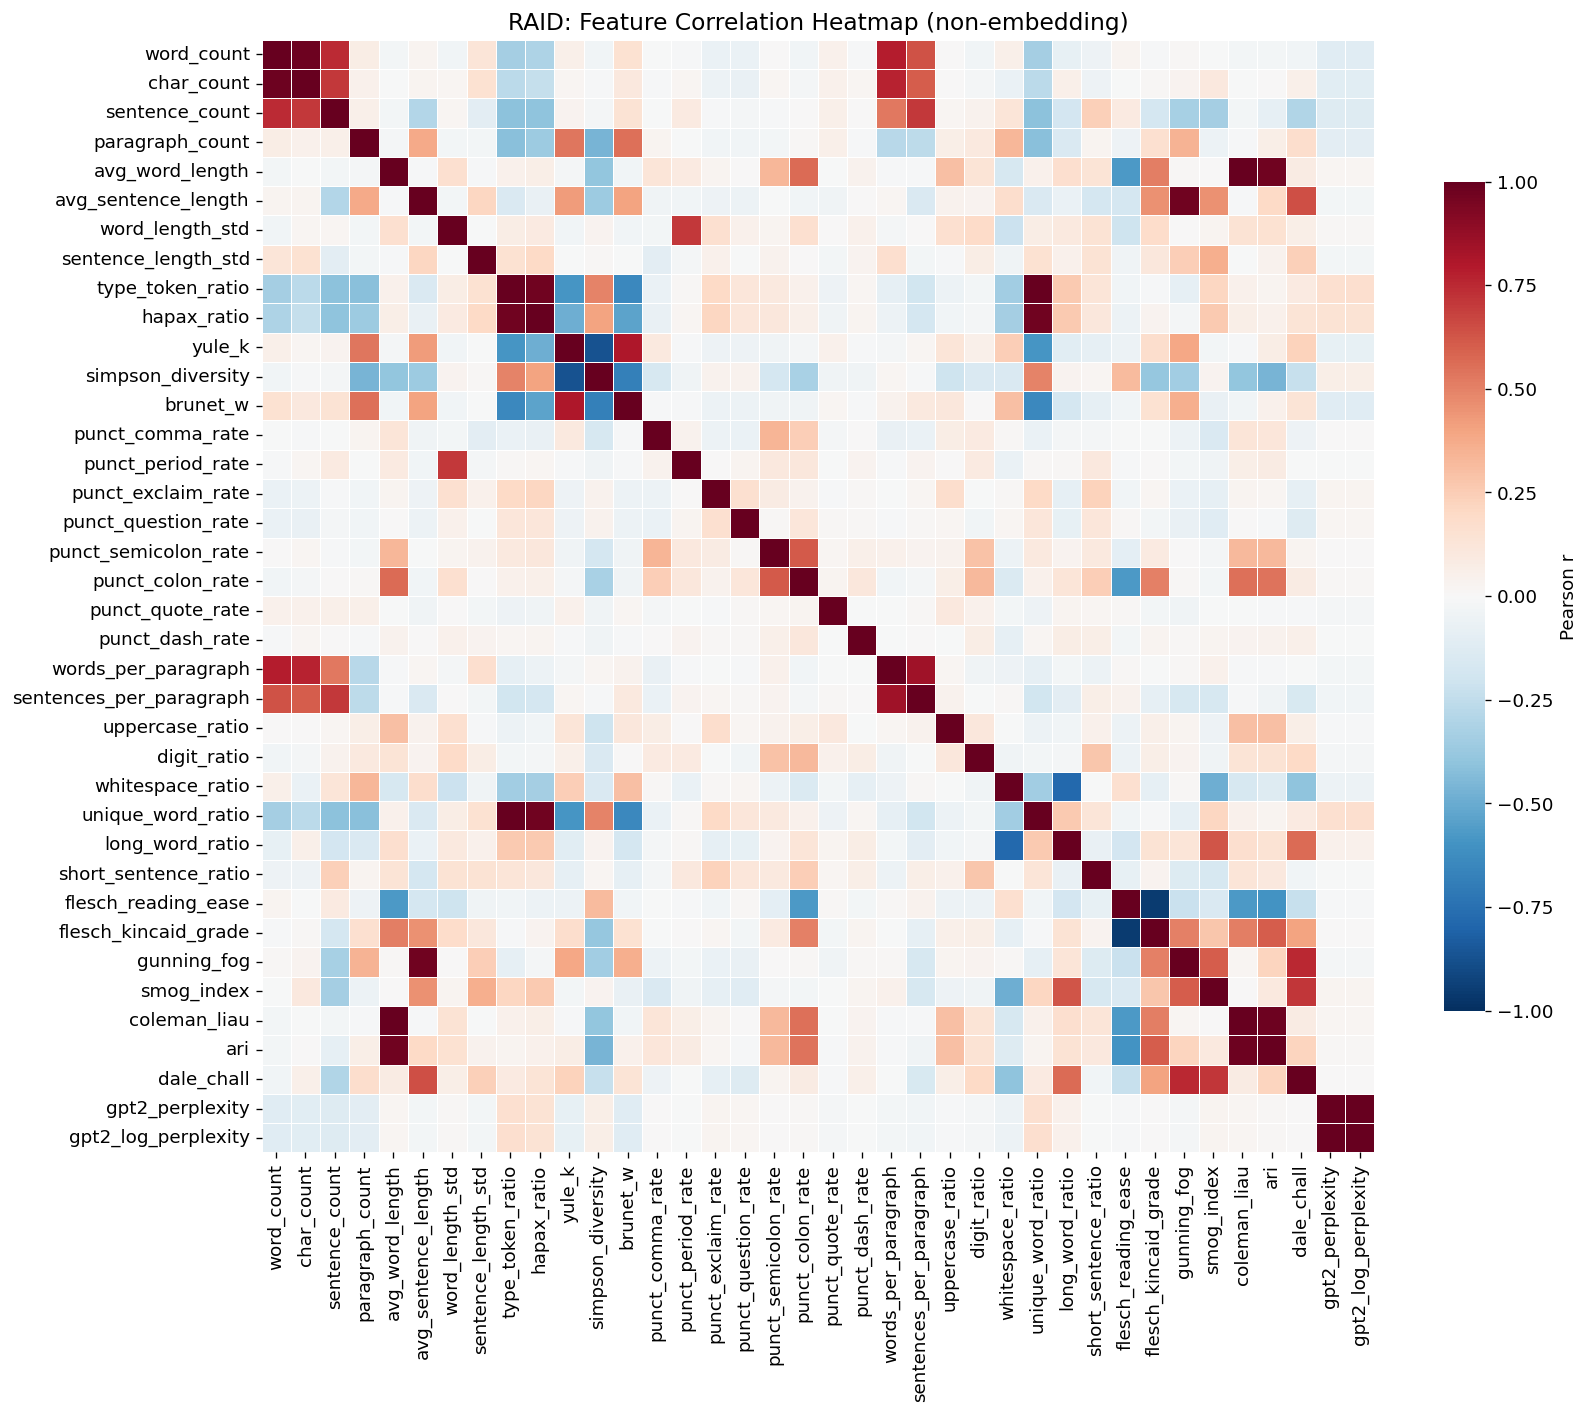

In [5]:
# 排除 emb_pca 展示非嵌入特征的相关性
non_emb = [c for c in X_test.columns if not c.startswith('emb_pca_')]
corr = X_test[non_emb].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}, ax=ax)
ax.set_title('RAID: Feature Correlation Heatmap (non-embedding)', fontsize=14)
plt.tight_layout()
plt.savefig(FIG / 'raid_nb_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 单特征 AUC 排名

对 90 个特征分别计算与标签的 AUC，衡量每个特征的独立判别力。

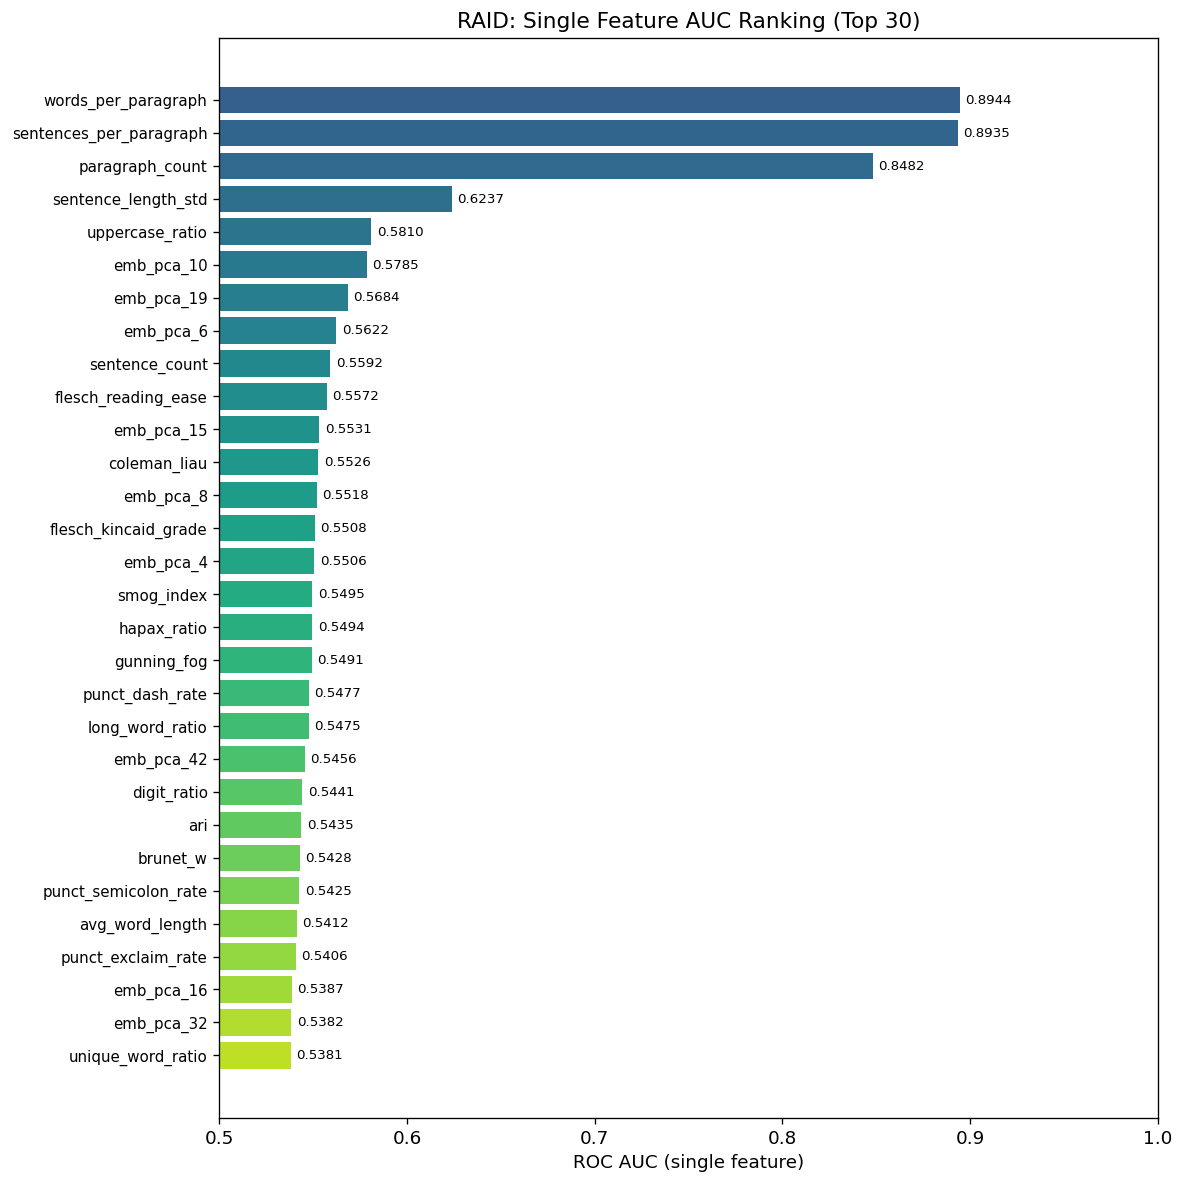


Top-10 单特征 AUC:
  words_per_paragraph            AUC=0.8944  Cohen_d=-0.866
  sentences_per_paragraph        AUC=0.8935  Cohen_d=-0.950
  paragraph_count                AUC=0.8482  Cohen_d=+0.796
  sentence_length_std            AUC=0.6237  Cohen_d=+0.003
  uppercase_ratio                AUC=0.5810  Cohen_d=-0.138
  emb_pca_10                     AUC=0.5785  Cohen_d=-0.285
  emb_pca_19                     AUC=0.5684  Cohen_d=-0.245
  emb_pca_6                      AUC=0.5622  Cohen_d=+0.210
  sentence_count                 AUC=0.5592  Cohen_d=-0.253
  flesch_reading_ease            AUC=0.5572  Cohen_d=-0.076


In [6]:
# 计算单特征 AUC
single_auc = []
for feat in X_test.columns:
    try:
        auc = roc_auc_score(y_test, X_test[feat].values)
        if auc < 0.5:
            auc = 1 - auc
    except:
        auc = 0.5
    h_vals = X_test[feat].values[y_test == 0]
    a_vals = X_test[feat].values[y_test == 1]
    pooled_std = np.sqrt((h_vals.std()**2 + a_vals.std()**2) / 2)
    cohen_d = (a_vals.mean() - h_vals.mean()) / pooled_std if pooled_std > 0 else 0
    single_auc.append({'feature': feat, 'auc': auc, 'cohen_d': cohen_d,
                       'mean_human': h_vals.mean(), 'mean_ai': a_vals.mean()})

stats_df = pd.DataFrame(single_auc).sort_values('auc', ascending=False).reset_index(drop=True)

# Top-30 柱状图
top30 = stats_df.head(30)
fig, ax = plt.subplots(figsize=(10, 10))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top30)))
ax.barh(range(len(top30)-1, -1, -1), top30['auc'].values, color=colors)
ax.set_yticks(range(len(top30)-1, -1, -1))
ax.set_yticklabels(top30['feature'].values, fontsize=9)
ax.set_xlabel('ROC AUC (single feature)')
ax.set_title('RAID: Single Feature AUC Ranking (Top 30)', fontsize=13)
ax.set_xlim(0.5, 1.0)
for i, v in enumerate(top30['auc'].values):
    ax.text(v + 0.003, len(top30)-1-i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('\nTop-10 单特征 AUC:')
for _, r in stats_df.head(10).iterrows():
    print(f"  {r['feature']:30s} AUC={r['auc']:.4f}  Cohen_d={r['cohen_d']:+.3f}")

### 3.3 Top-12 特征分布对比 (Human vs AI)

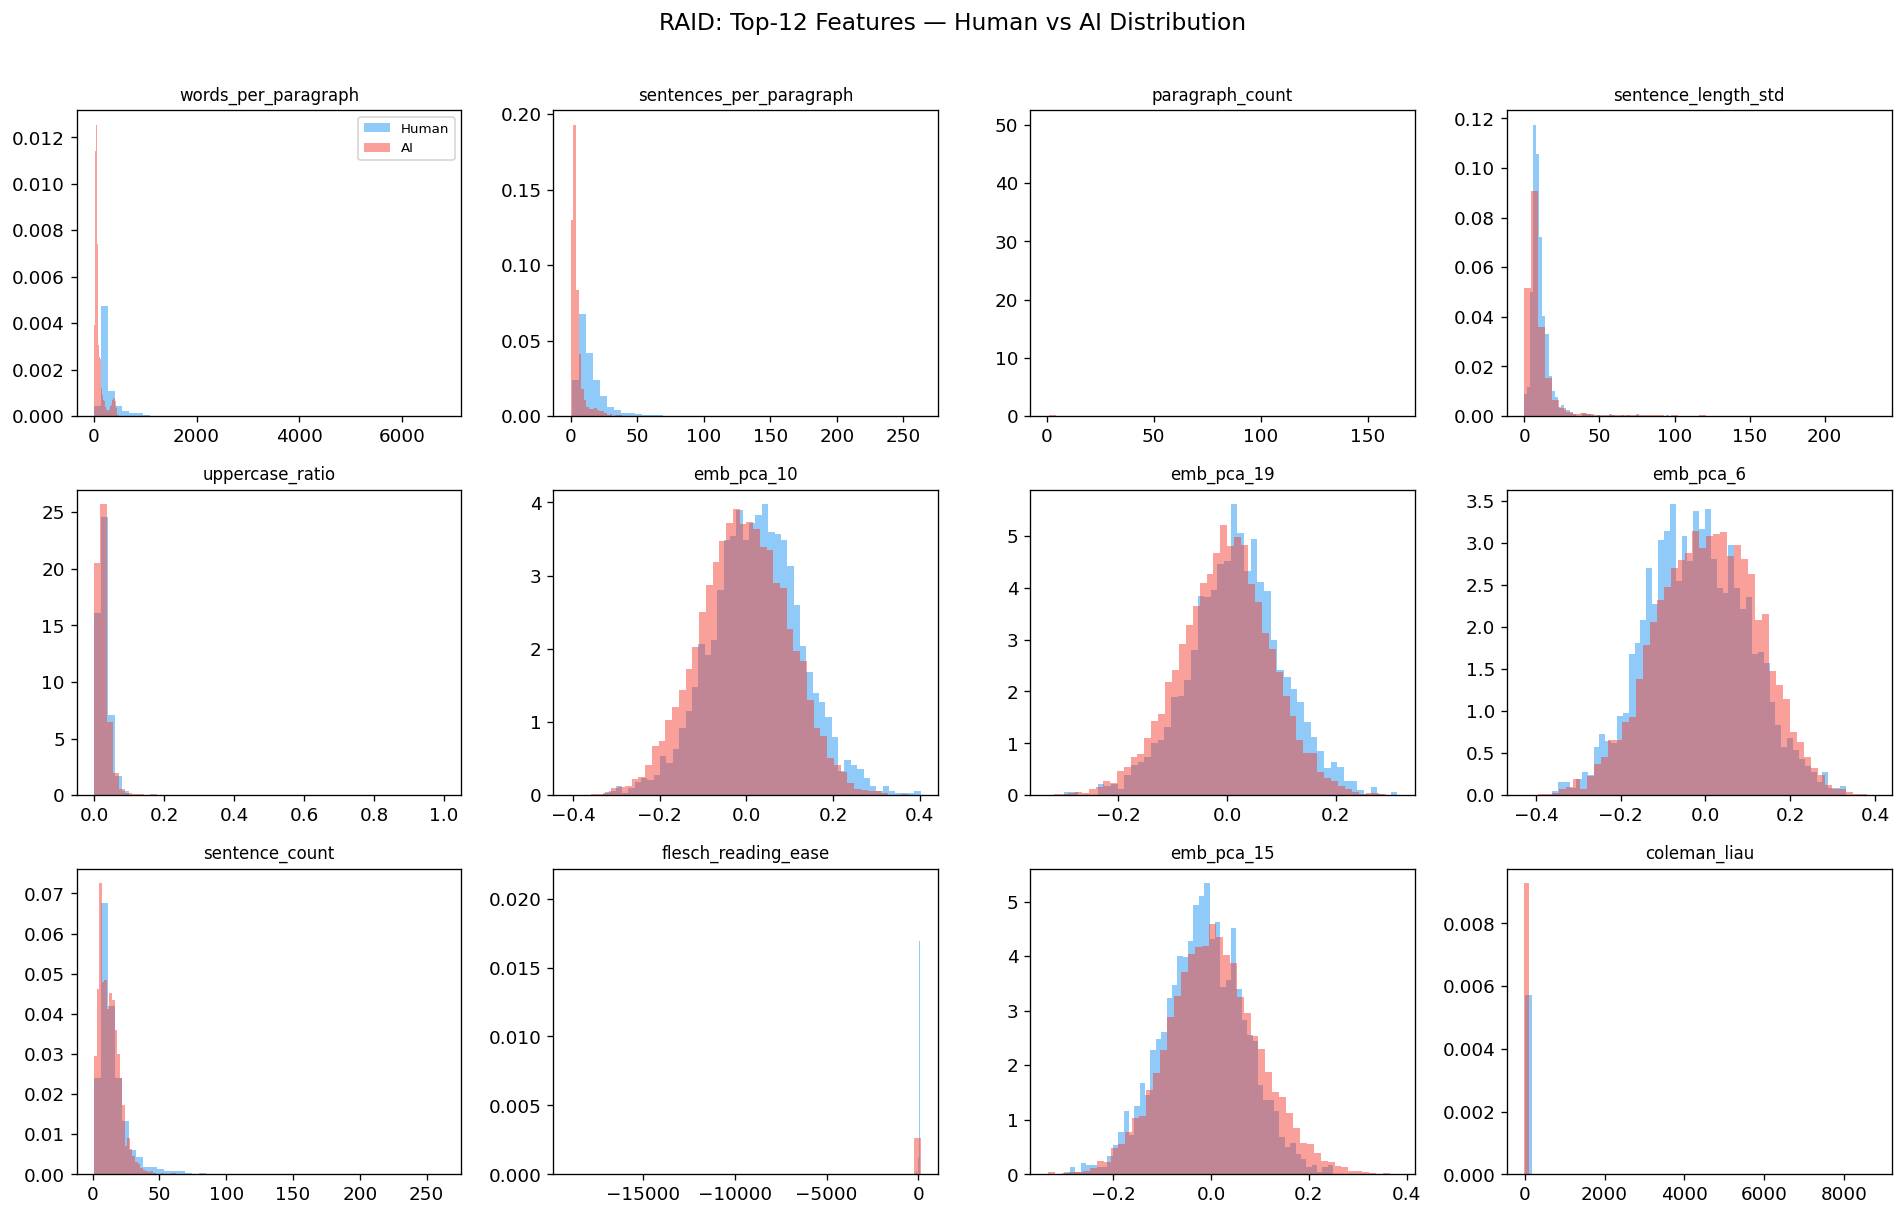

In [7]:
top12 = stats_df.head(12)['feature'].values

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for idx, (feat, ax) in enumerate(zip(top12, axes.flat)):
    h_vals = X_test[feat].values[y_test == 0]
    a_vals = X_test[feat].values[y_test == 1]
    ax.hist(h_vals, bins=50, density=True, alpha=0.5, color='#2196F3', label='Human')
    ax.hist(a_vals, bins=50, density=True, alpha=0.5, color='#F44336', label='AI')
    ax.set_title(feat, fontsize=10)
    if idx == 0:
        ax.legend(fontsize=8)
plt.suptitle('RAID: Top-12 Features — Human vs AI Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

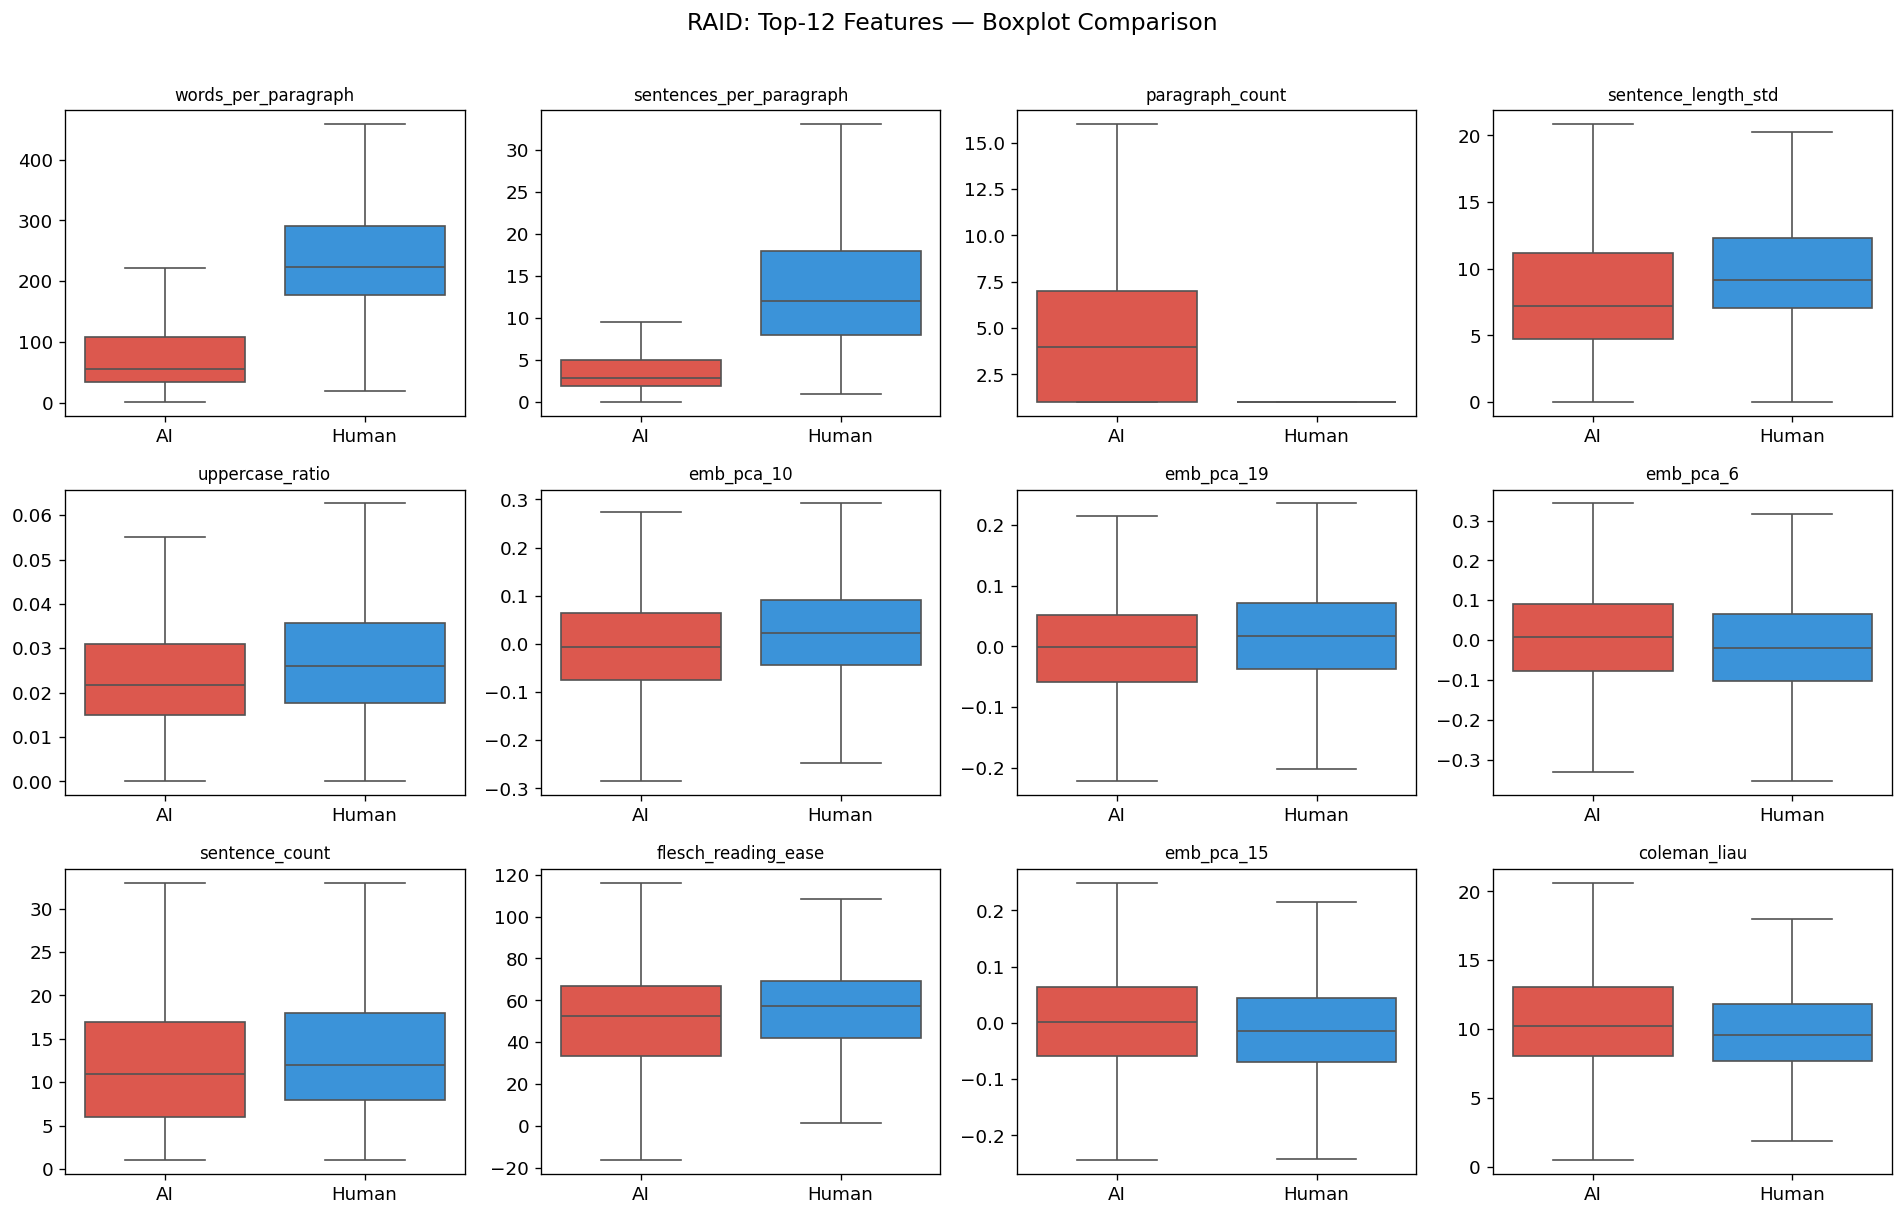

In [8]:
# Top-12 箱线图
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for idx, (feat, ax) in enumerate(zip(top12, axes.flat)):
    plot_data = pd.DataFrame({
        'value': X_test[feat].values,
        'label': ['Human' if y == 0 else 'AI' for y in y_test]
    })
    sns.boxplot(data=plot_data, x='label', y='value', ax=ax,
                palette={'Human': '#2196F3', 'AI': '#F44336'}, showfliers=False)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.suptitle('RAID: Top-12 Features — Boxplot Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. 降维可视化

### 4.1 PCA

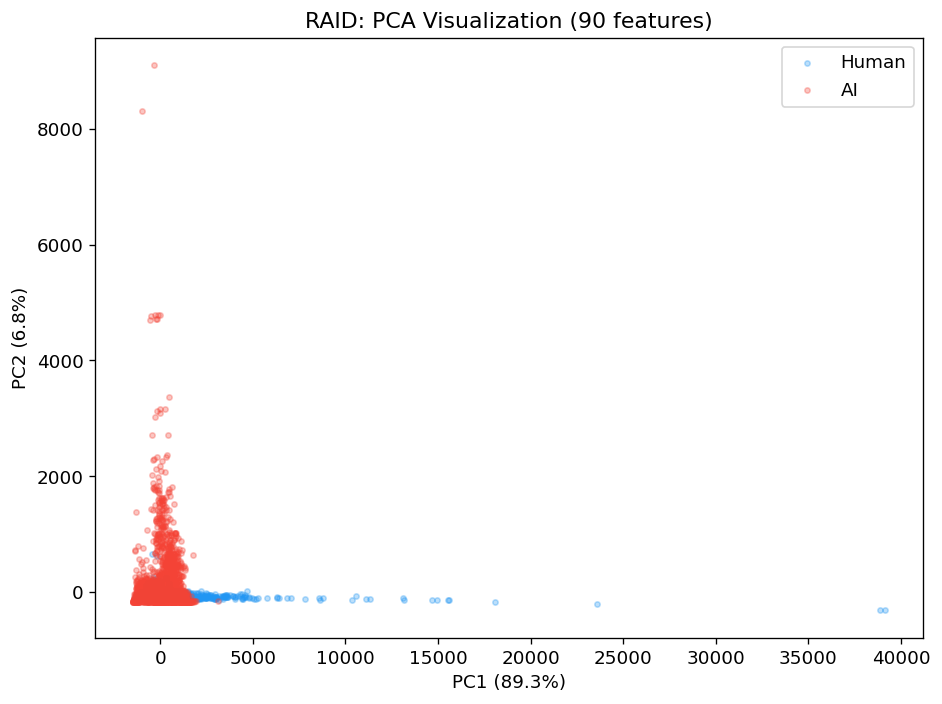

In [9]:
# PCA 2D
n_vis = min(8000, len(X_test))
idx_vis = np.random.RandomState(SEED).choice(len(X_test), n_vis, replace=False)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_test.iloc[idx_vis])

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, '#2196F3', 'Human'), (1, '#F44336', 'AI')]:
    mask = y_test[idx_vis] == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.3, s=10, label=name)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('RAID: PCA Visualization (90 features)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 t-SNE

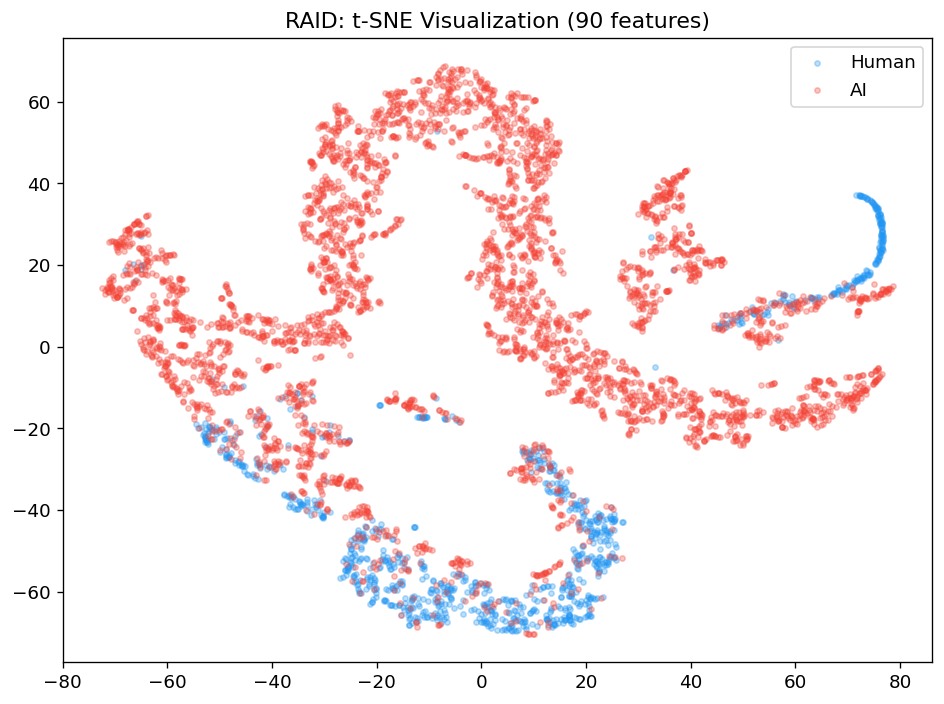

In [10]:
n_tsne = min(5000, len(X_test))
idx_t = np.random.RandomState(SEED).choice(len(X_test), n_tsne, replace=False)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_2d = tsne.fit_transform(X_test.iloc[idx_t])

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, '#2196F3', 'Human'), (1, '#F44336', 'AI')]:
    mask = y_test[idx_t] == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, alpha=0.3, s=10, label=name)
ax.set_title('RAID: t-SNE Visualization (90 features)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. 模型训练与评估

对比三种可解释分类器：XGBoost、Logistic Regression、Random Forest。

In [11]:
# XGBoost
clf_xgb = XGBClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=SEED,
    tree_method='hist', device='cuda'
)
clf_xgb.fit(X_train, y_train, verbose=False)

y_prob_xgb = clf_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = clf_xgb.predict(X_test)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f'=== XGBoost (90 features) ===')
print(f'AUC:      {auc_xgb:.4f}')
print(f'Accuracy: {acc_xgb:.4f}')
print(classification_report(y_test, y_pred_xgb, target_names=['Human', 'AI']))

=== XGBoost (90 features) ===
AUC:      0.9951
Accuracy: 0.9714
              precision    recall  f1-score   support

       Human       0.91      0.96      0.93      2674
          AI       0.99      0.98      0.98     10001

    accuracy                           0.97     12675
   macro avg       0.95      0.97      0.96     12675
weighted avg       0.97      0.97      0.97     12675



In [12]:
# Logistic Regression
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

clf_lr = LogisticRegression(max_iter=2000, random_state=SEED, C=1.0)
clf_lr.fit(X_tr_s, y_train)

y_prob_lr = clf_lr.predict_proba(X_te_s)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)
acc_lr = accuracy_score(y_test, clf_lr.predict(X_te_s))

# Random Forest
clf_rf = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=SEED, n_jobs=-1)
clf_rf.fit(X_train, y_train)

y_prob_rf = clf_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
acc_rf = accuracy_score(y_test, clf_rf.predict(X_test))

# 汇总
results_90 = pd.DataFrame([
    {'Method': 'XGBoost', 'AUC': auc_xgb, 'Accuracy': acc_xgb},
    {'Method': 'Logistic Regression', 'AUC': auc_lr, 'Accuracy': acc_lr},
    {'Method': 'Random Forest', 'AUC': auc_rf, 'Accuracy': acc_rf},
])

print('=== 90 特征分类器对比 ===')
print(results_90.to_string(index=False))

=== 90 特征分类器对比 ===
             Method      AUC  Accuracy
            XGBoost 0.995093  0.971361
Logistic Regression 0.965298  0.911716
      Random Forest 0.992250  0.962209


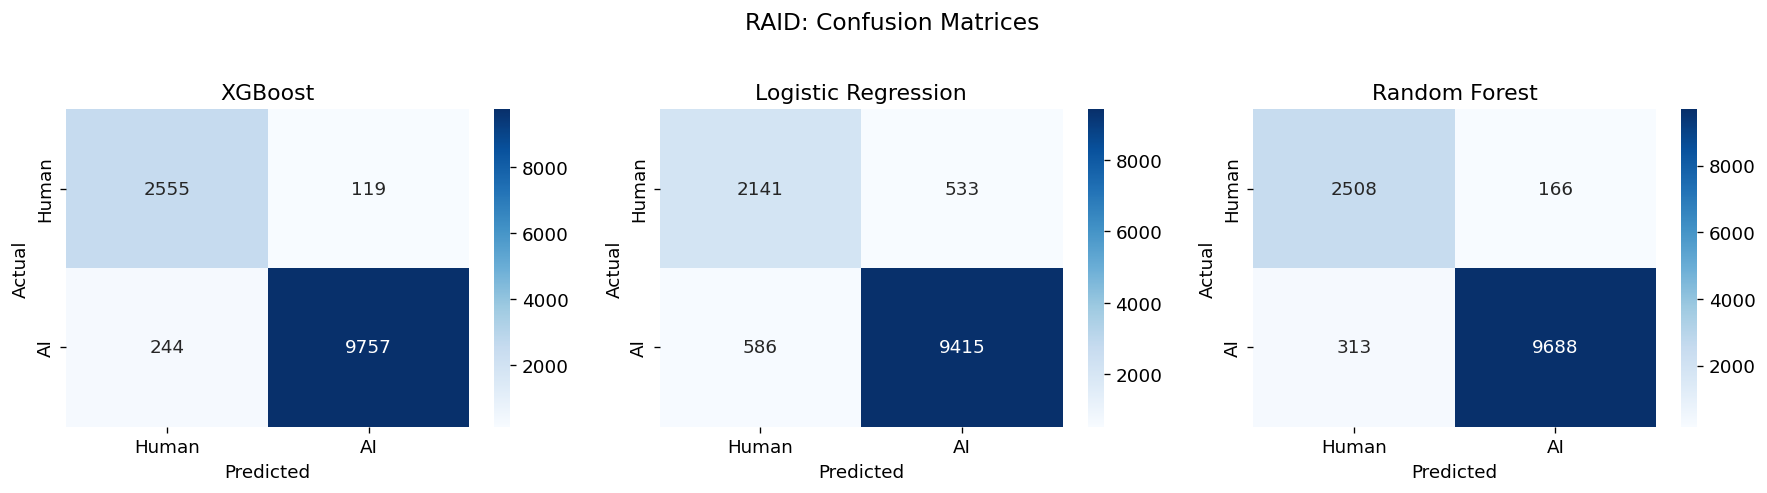

In [13]:
# 混淆矩阵
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, [
    ('XGBoost', y_pred_xgb),
    ('Logistic Regression', clf_lr.predict(X_te_s)),
    ('Random Forest', clf_rf.predict(X_test)),
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('RAID: Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. SHAP 可解释性分析

使用 SHAP (TreeExplainer) 对 XGBoost 模型进行归因分析，量化解释每个特征对分类决策的贡献。

In [14]:
# SHAP
explainer = shap.TreeExplainer(clf_xgb)
n_shap = min(3000, len(X_test))
X_shap = X_test.iloc[:n_shap]
shap_values = explainer.shap_values(X_shap)

print(f'SHAP computed on {n_shap} samples, {X_shap.shape[1]} features')

SHAP computed on 3000 samples, 88 features


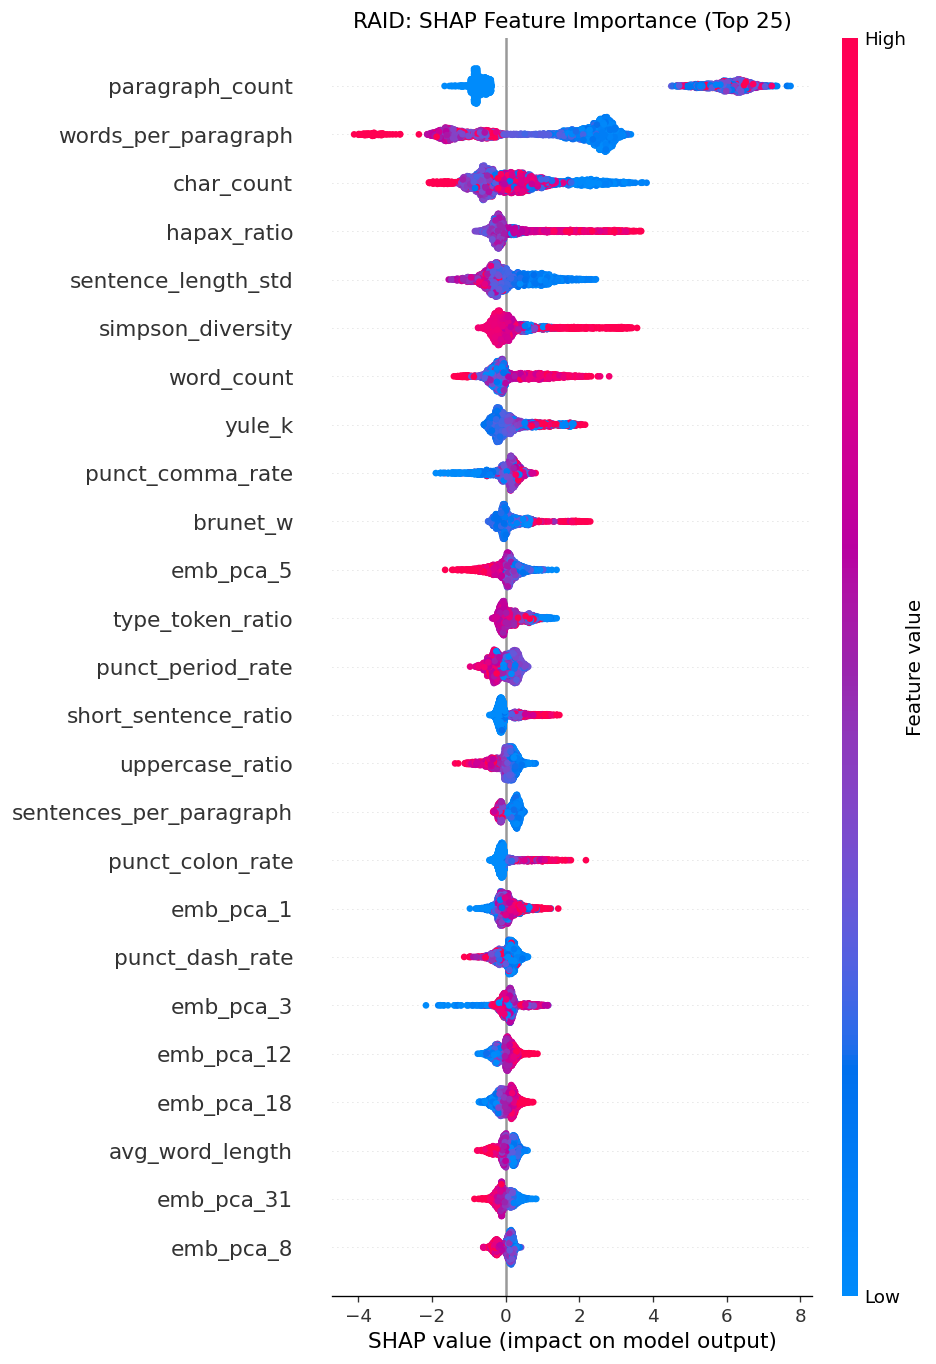

In [15]:
# SHAP Summary (beeswarm)
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_shap, max_display=25, show=False)
plt.title('RAID: SHAP Feature Importance (Top 25)', fontsize=13)
plt.tight_layout()
plt.show()

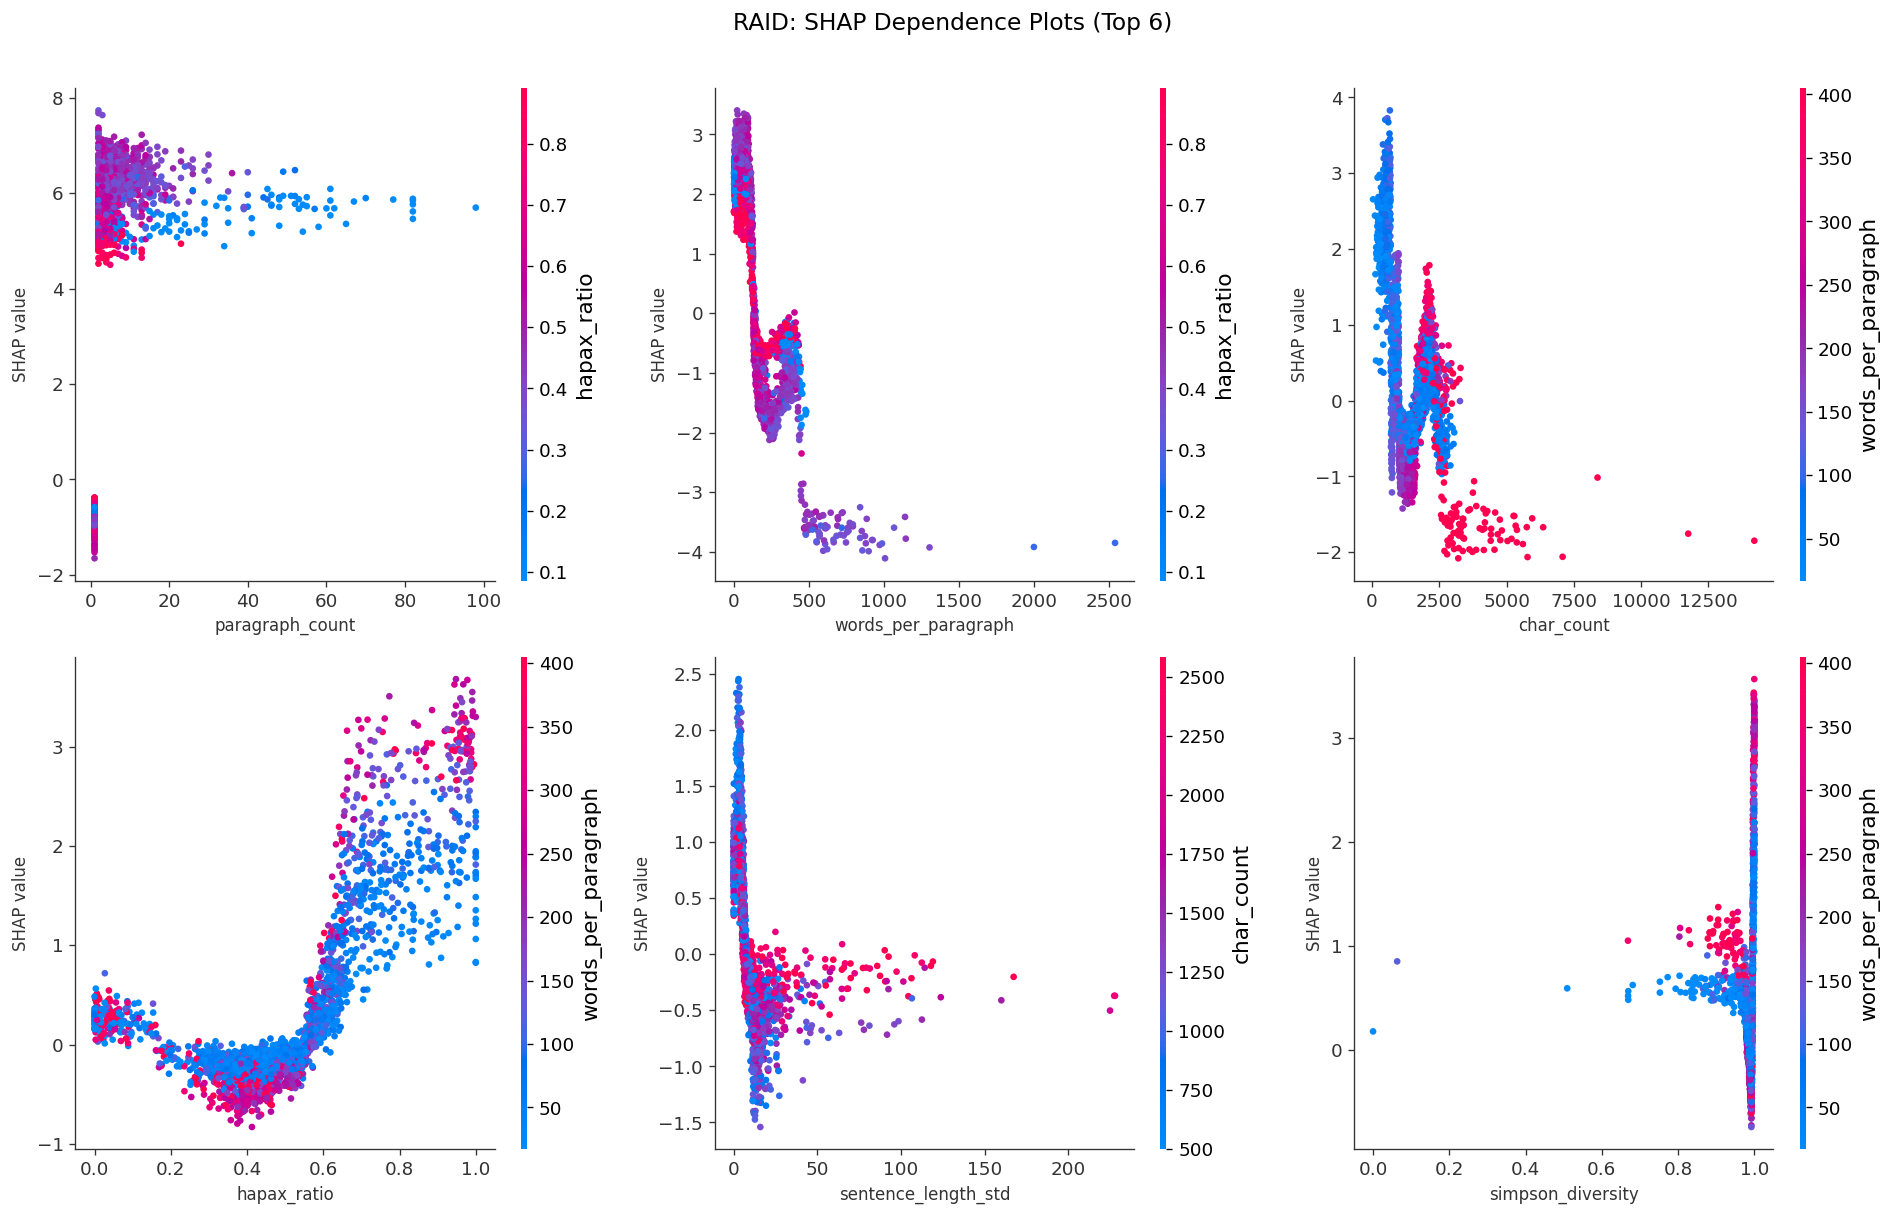

In [16]:
# SHAP Dependence — Top 6 特征
mean_abs = np.abs(shap_values).mean(axis=0)
top6_idx = np.argsort(mean_abs)[::-1][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, fi in zip(axes.flat, top6_idx):
    feat_name = X_shap.columns[fi]
    shap.dependence_plot(fi, shap_values, X_shap, ax=ax, show=False)
    ax.set_xlabel(feat_name, fontsize=10)
    ax.set_ylabel('SHAP value', fontsize=10)
plt.suptitle('RAID: SHAP Dependence Plots (Top 6)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

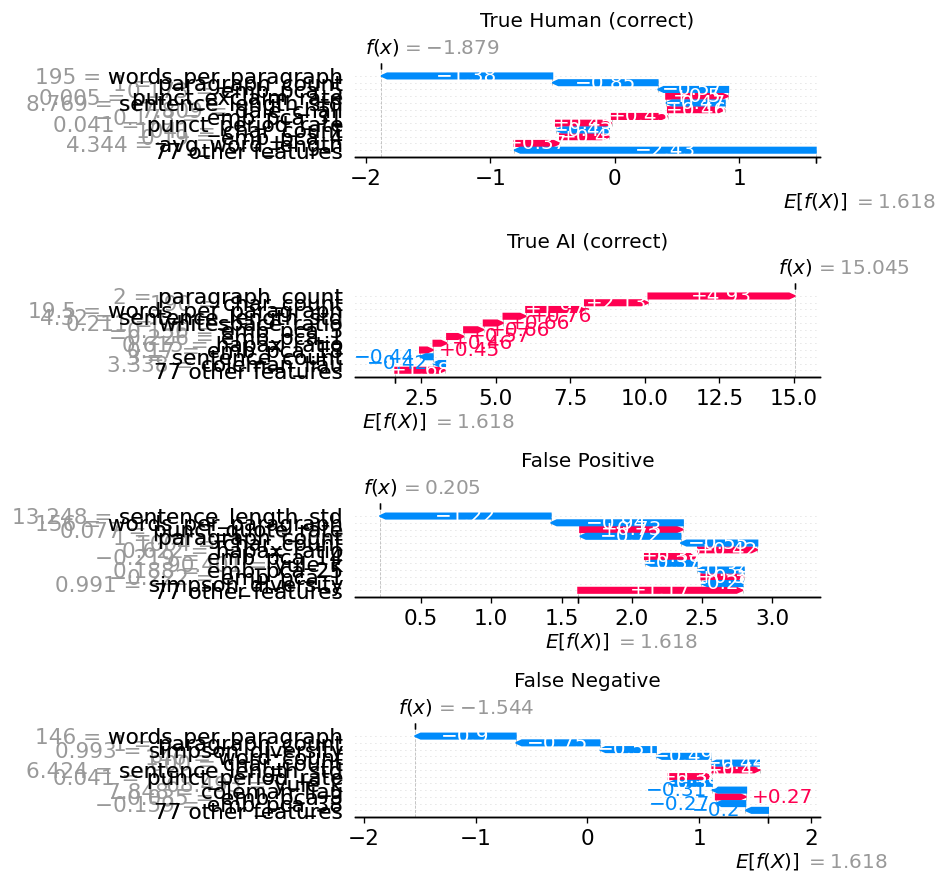

In [17]:
# SHAP Waterfall — 4 典型案例
y_pred_shap = clf_xgb.predict(X_shap)
y_shap = y_test[:n_shap]

cases = {}
for name, cond in [
    ('True Human (correct)', (y_shap == 0) & (y_pred_shap == 0)),
    ('True AI (correct)',     (y_shap == 1) & (y_pred_shap == 1)),
    ('False Positive',       (y_shap == 0) & (y_pred_shap == 1)),
    ('False Negative',       (y_shap == 1) & (y_pred_shap == 0)),
]:
    idxs = np.where(cond)[0]
    if len(idxs) > 0:
        cases[name] = idxs[0]

if cases:
    fig, axes = plt.subplots(len(cases), 1, figsize=(12, 4 * len(cases)))
    if len(cases) == 1:
        axes = [axes]
    for ax, (name, ci) in zip(axes, cases.items()):
        exp = shap.Explanation(
            values=shap_values[ci],
            base_values=explainer.expected_value,
            data=X_shap.iloc[ci].values,
            feature_names=X_shap.columns.tolist()
        )
        plt.sca(ax)
        shap.waterfall_plot(exp, max_display=12, show=False)
        ax.set_title(name, fontsize=12)
    plt.tight_layout()
    plt.show()

---
## 7. 特征消融实验

将 90 个特征按组拆分，分别训练 XGBoost，验证各特征组的独立判别力。

  basic_counts         ( 4 feats): AUC = 0.9719


  averages             ( 4 feats): AUC = 0.9665


  variability          ( 2 feats): AUC = 0.6830


  lexical_richness     ( 7 feats): AUC = 0.8503


  punctuation          (11 feats): AUC = 0.8617


  readability          ( 7 feats): AUC = 0.6966


  structure            ( 1 feats): AUC = 0.5955


  embedding_pca        (50 feats): AUC = 0.7624


  perplexity           ( 2 feats): AUC = 0.4920


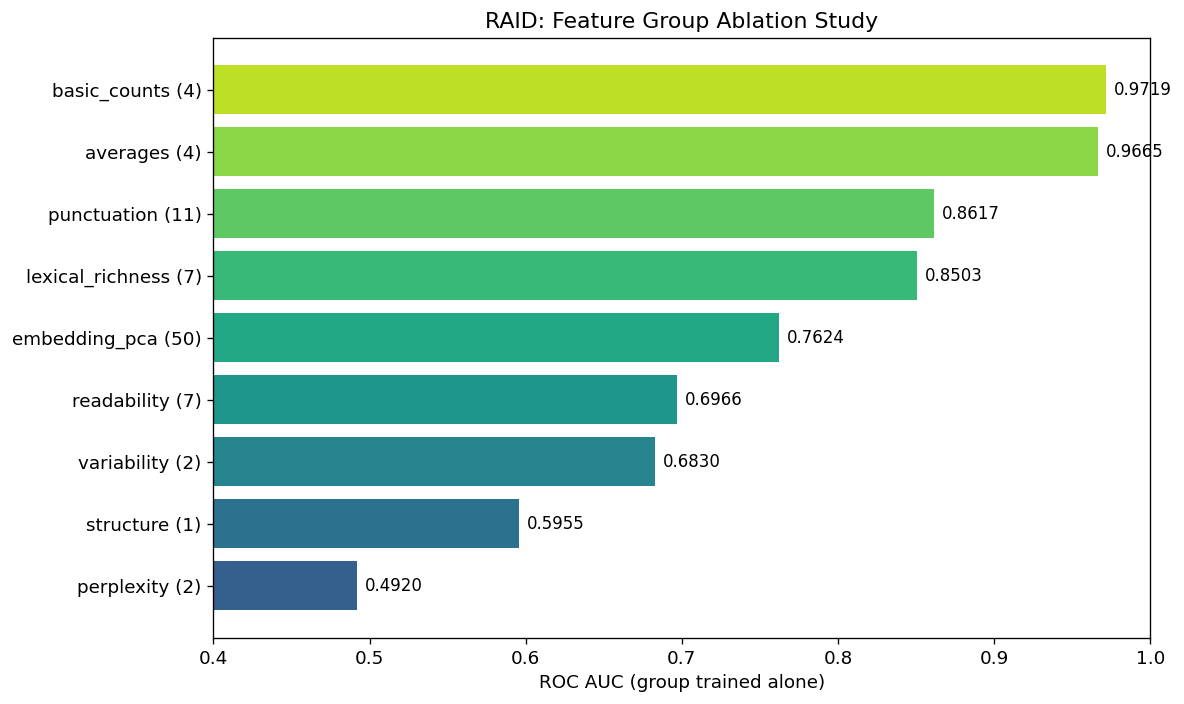


⚠️ 关键发现: perplexity 在多模型 RAID 上完全失效 (AUC ≈ 0.49)，但在单模型 HC3 上是最强特征 (AUC = 0.99)


In [18]:
groups = {
    'basic_counts': ['word_count', 'char_count', 'sentence_count', 'paragraph_count'],
    'averages': ['avg_word_length', 'avg_sentence_length', 'words_per_paragraph', 'sentences_per_paragraph'],
    'variability': ['word_length_std', 'sentence_length_std'],
    'lexical_richness': ['type_token_ratio', 'hapax_ratio', 'yule_k', 'simpson_diversity',
                         'brunet_w', 'unique_word_ratio', 'long_word_ratio'],
    'punctuation': [c for c in X_train.columns if c.startswith('punct_')] +
                   ['uppercase_ratio', 'digit_ratio', 'whitespace_ratio'],
    'readability': ['flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog',
                    'smog_index', 'coleman_liau', 'ari', 'dale_chall'],
    'structure': ['short_sentence_ratio'],
    'embedding_pca': [c for c in X_train.columns if c.startswith('emb_pca_')],
    'perplexity': ['gpt2_perplexity', 'gpt2_log_perplexity'],
}

ablation = {}
for gname, feats in groups.items():
    feats = [f for f in feats if f in X_train.columns]
    if not feats:
        continue
    clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                        eval_metric='logloss', random_state=SEED,
                        tree_method='hist', device='cuda')
    clf.fit(X_train[feats], y_train, verbose=False)
    y_prob = clf.predict_proba(X_test[feats])[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    ablation[gname] = {'auc': auc, 'n_feats': len(feats)}
    print(f'  {gname:20s} ({len(feats):2d} feats): AUC = {auc:.4f}')

# 柱状图
sorted_g = sorted(ablation.items(), key=lambda x: x[1]['auc'], reverse=True)
names = [f"{g} ({r['n_feats']})" for g, r in sorted_g]
aucs  = [r['auc'] for _, r in sorted_g]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(names)))
ax.barh(names[::-1], aucs[::-1], color=colors)
ax.set_xlim(0.4, 1.0)
ax.set_xlabel('ROC AUC (group trained alone)')
ax.set_title('RAID: Feature Group Ablation Study')
for i, v in enumerate(aucs[::-1]):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print('\n⚠️ 关键发现: perplexity 在多模型 RAID 上完全失效 (AUC ≈ 0.49)，但在单模型 HC3 上是最强特征 (AUC = 0.99)')

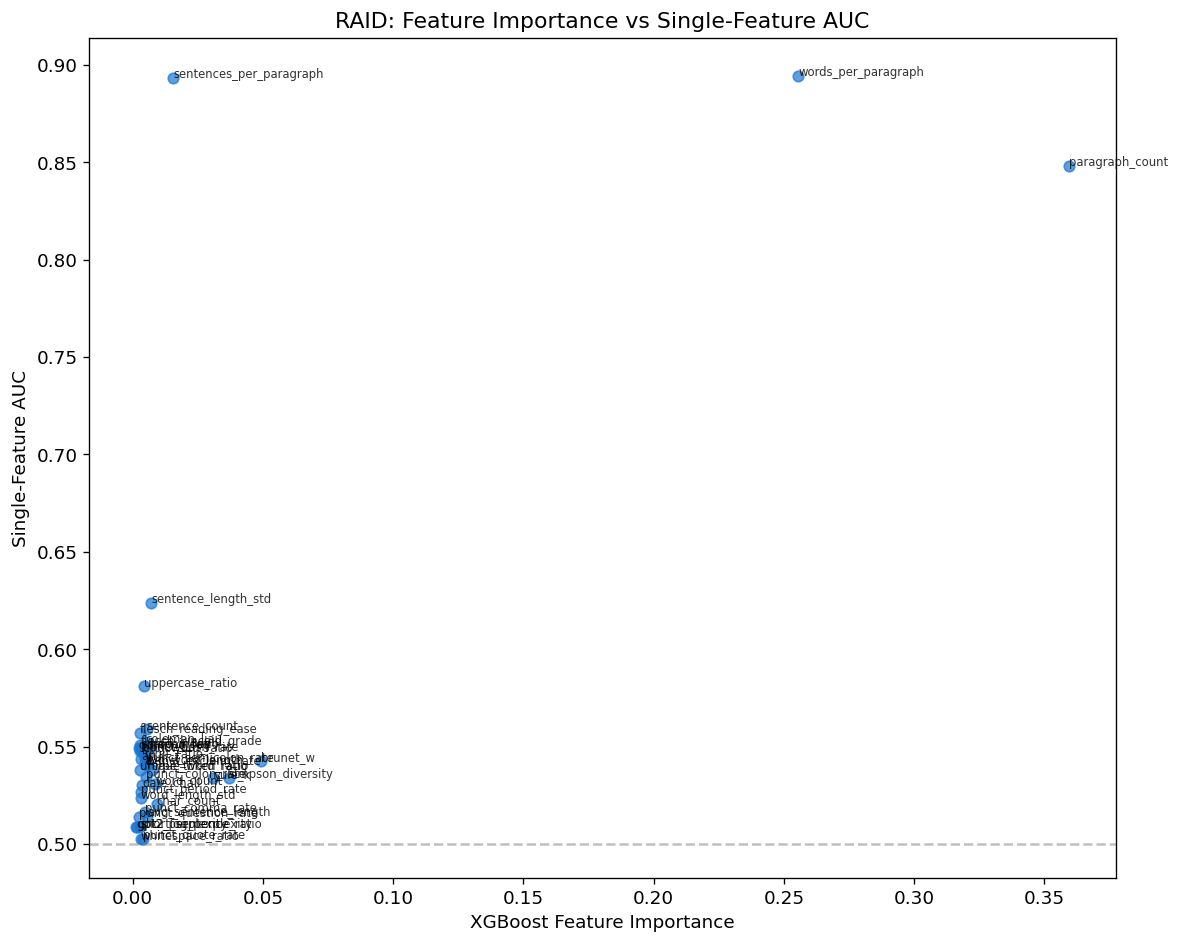

In [19]:
# Feature Importance vs 单特征 AUC
imp = pd.Series(clf_xgb.feature_importances_, index=X_train.columns)
show = stats_df[~stats_df['feature'].str.startswith('emb_pca_')].copy()
show['importance'] = show['feature'].map(imp)
show = show.dropna(subset=['importance'])

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(show['importance'], show['auc'], alpha=0.7, s=40, c='#1976D2')
for _, r in show.iterrows():
    ax.annotate(r['feature'], (r['importance'], r['auc']), fontsize=7, alpha=0.8)
ax.set_xlabel('XGBoost Feature Importance')
ax.set_ylabel('Single-Feature AUC')
ax.set_title('RAID: Feature Importance vs Single-Feature AUC')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 7.1 LR 系数分析

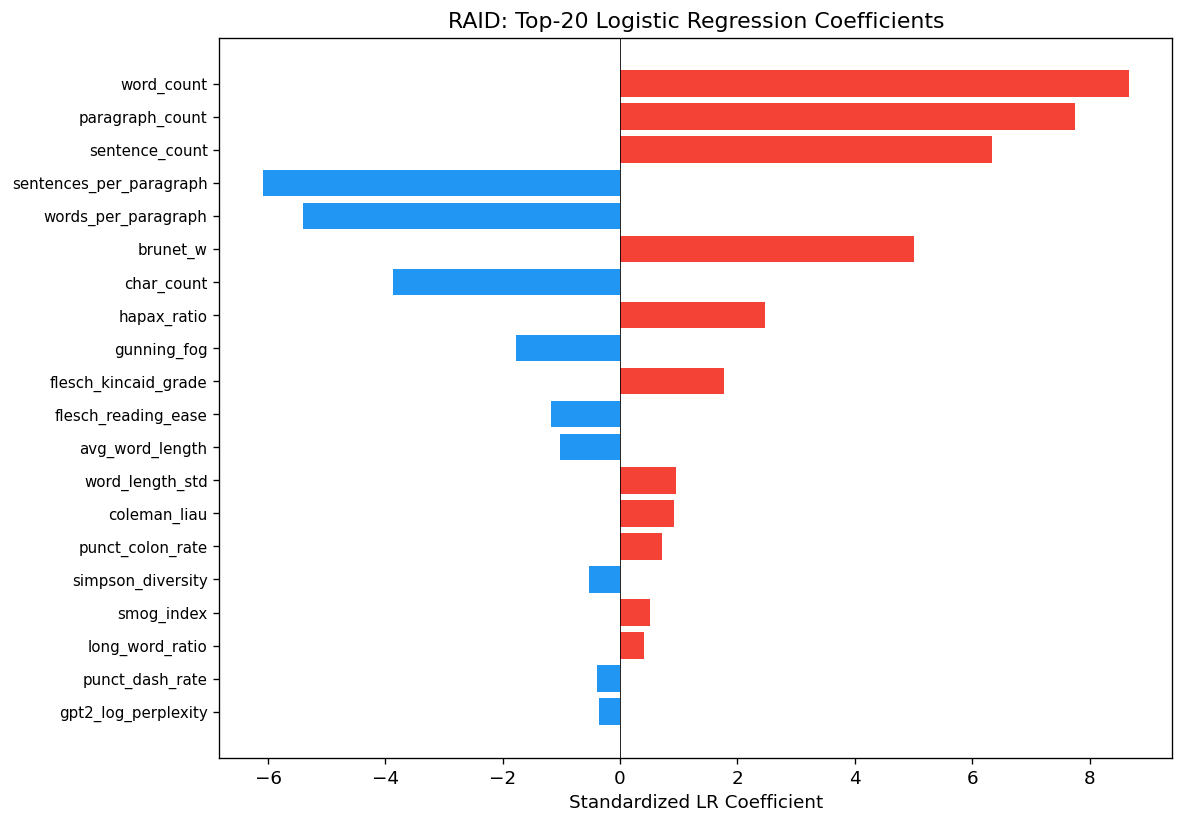

红色 = 正系数 (指向 AI)，蓝色 = 负系数 (指向 Human)


In [20]:
# LR Top-20 系数（标准化后）
coefs = clf_lr.coef_[0]
top_idx = np.argsort(np.abs(coefs))[::-1][:20]
top_names = [X_train.columns[i] for i in top_idx]
top_coefs = coefs[top_idx]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#F44336' if c > 0 else '#2196F3' for c in top_coefs]
ax.barh(range(len(top_names)-1, -1, -1), top_coefs, color=colors)
ax.set_yticks(range(len(top_names)-1, -1, -1))
ax.set_yticklabels(top_names, fontsize=9)
ax.set_xlabel('Standardized LR Coefficient')
ax.set_title('RAID: Top-20 Logistic Regression Coefficients')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('红色 = 正系数 (指向 AI)，蓝色 = 负系数 (指向 Human)')

---
## 8. RAID 独有分析

### 8.1 Per-Generator 特征雷达图

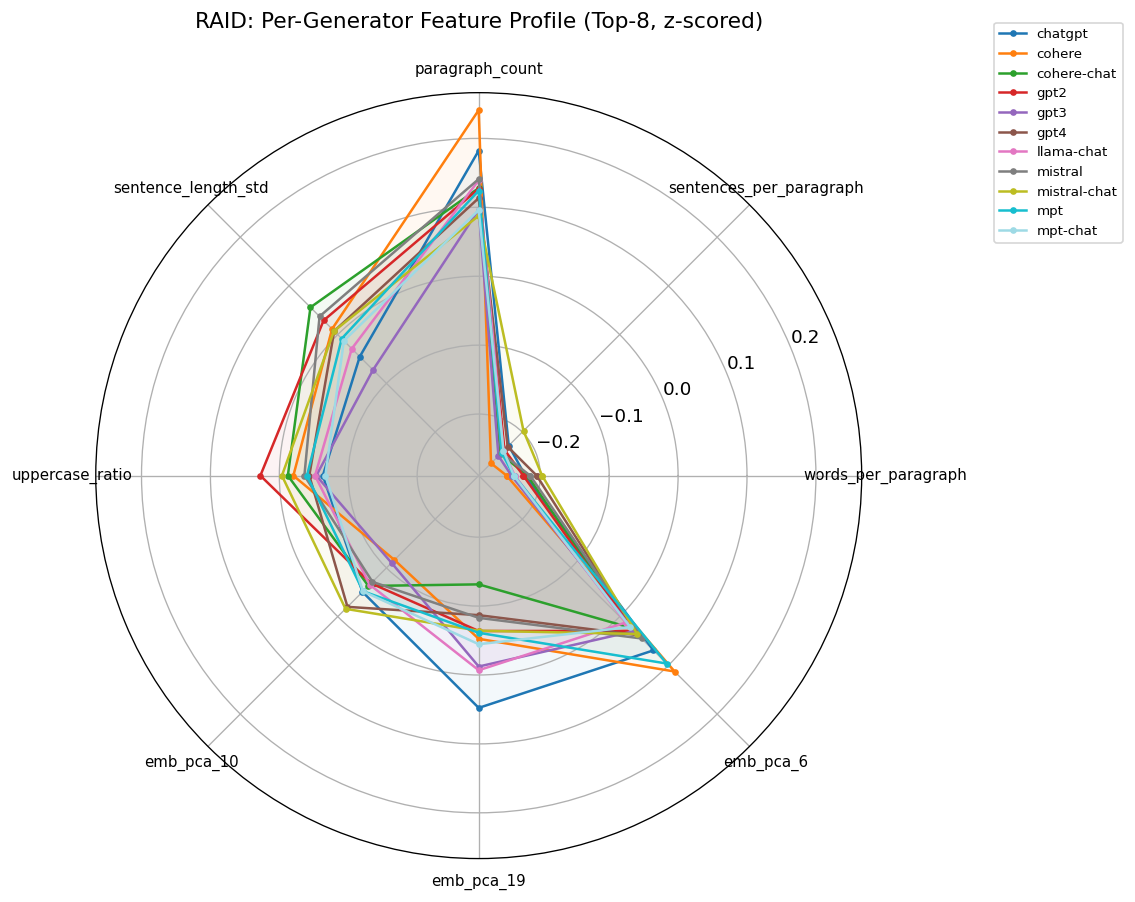

In [21]:
top8_feats = stats_df.head(8)['feature'].values
scaler_r = StandardScaler()
X_scaled = pd.DataFrame(scaler_r.fit_transform(X_test[top8_feats]), columns=top8_feats)
X_scaled['model'] = test_df['model'].values

means = X_scaled.groupby('model')[list(top8_feats)].mean()
means = means.drop('human', errors='ignore')

angles = np.linspace(0, 2 * np.pi, len(top8_feats), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
cmap = plt.cm.tab20(np.linspace(0, 1, len(means)))
for i, (model, row) in enumerate(means.iterrows()):
    values = row.values.tolist() + [row.values[0]]
    ax.plot(angles, values, 'o-', linewidth=1.5, label=model, color=cmap[i], markersize=3)
    ax.fill(angles, values, alpha=0.05, color=cmap[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(top8_feats, fontsize=9)
ax.set_title('RAID: Per-Generator Feature Profile (Top-8, z-scored)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

### 8.2 Per-Model 检测准确率

Per-Generator 检测准确率 (XGBoost):
   Generator  Accuracy    N
         mpt  0.985035 1136
      cohere  0.981878  607
        gpt3  0.978947  570
    mpt-chat  0.975510 1225
     mistral  0.975309 1215
 cohere-chat  0.975124  603
  llama-chat  0.974662 1184
mistral-chat  0.973615 1137
        gpt4  0.973545  567
        gpt2  0.971503 1158
     chatgpt  0.964942  599


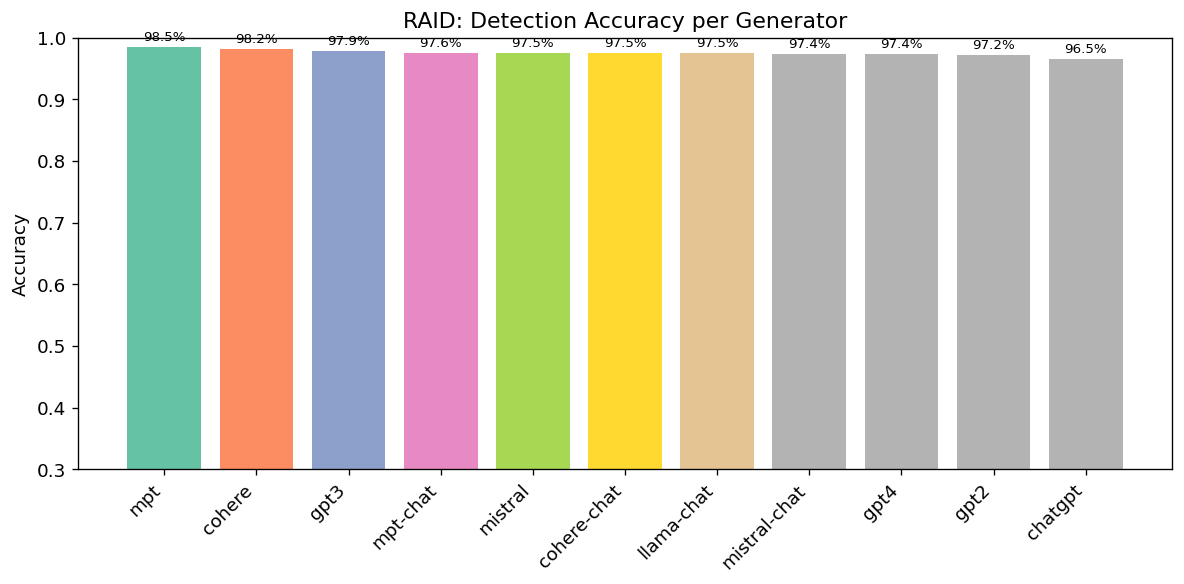

In [22]:
# Per-model accuracy
models = [m for m in test_df['model'].unique() if m != 'human']
per_model = []
for m in sorted(models):
    mask = test_df['model'] == m
    if mask.sum() < 10:
        continue
    y_m = y_test[mask]
    p_m = y_pred_xgb[mask]
    acc = accuracy_score(y_m, p_m)
    per_model.append({'Generator': m, 'Accuracy': acc, 'N': mask.sum()})

pm_df = pd.DataFrame(per_model).sort_values('Accuracy', ascending=False)
print('Per-Generator 检测准确率 (XGBoost):')
print(pm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pm_df['Generator'], pm_df['Accuracy'], color=plt.cm.Set2(range(len(pm_df))))
ax.set_ylabel('Accuracy')
ax.set_title('RAID: Detection Accuracy per Generator')
ax.set_ylim(0.3, 1.0)
plt.xticks(rotation=45, ha='right')
for i, (_, r) in enumerate(pm_df.iterrows()):
    ax.text(i, r['Accuracy'] + 0.01, f"{r['Accuracy']:.1%}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### 8.3 域特征对比 (8 domains)

Per-Domain AUC (XGBoost):
   Domain      AUC    N
  recipes 0.998122 1687
     wiki 0.997116 1745
   reddit 0.996510 1728
     news 0.996438 1676
    books 0.995325 1694
   poetry 0.995220 1646
  reviews 0.993376  876
abstracts 0.990571 1623


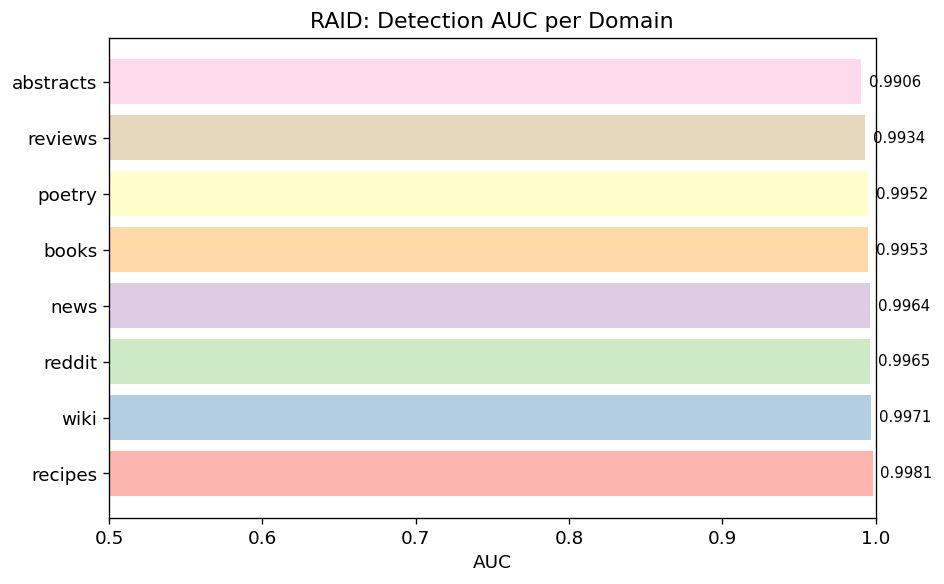

In [23]:
# Per-domain AUC
domains = test_df['domain'].unique()
per_domain = []
for d in sorted(domains):
    mask = test_df['domain'] == d
    if mask.sum() < 20:
        continue
    try:
        auc = roc_auc_score(y_test[mask], y_prob_xgb[mask])
    except:
        auc = np.nan
    per_domain.append({'Domain': d, 'AUC': auc, 'N': mask.sum()})

pd_df = pd.DataFrame(per_domain).sort_values('AUC', ascending=False)
print('Per-Domain AUC (XGBoost):')
print(pd_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(pd_df['Domain'], pd_df['AUC'], color=plt.cm.Pastel1(range(len(pd_df))))
ax.set_xlabel('AUC')
ax.set_xlim(0.5, 1.0)
ax.set_title('RAID: Detection AUC per Domain')
for i, (_, r) in enumerate(pd_df.iterrows()):
    ax.text(r['AUC'] + 0.005, i, f"{r['AUC']:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 8.4 对抗攻击鲁棒性分析

展示已生成的对抗攻击分析结果。

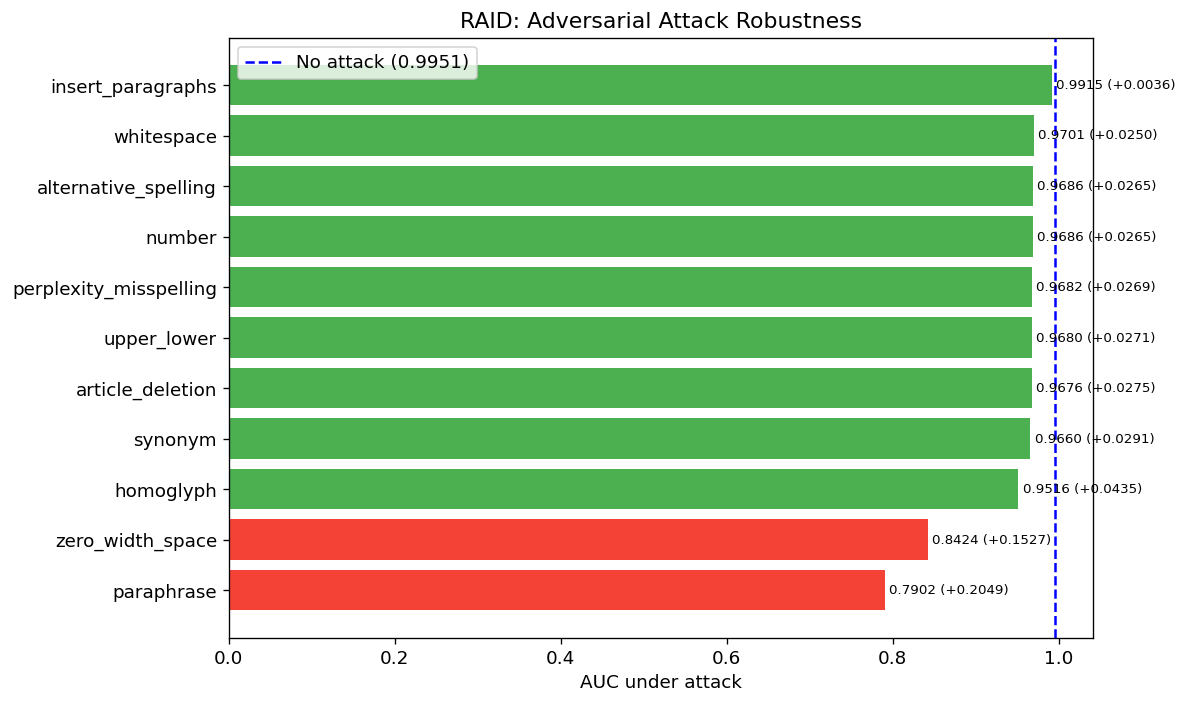


Baseline AUC (no attack): 0.9951
Paraphrase 是唯一显著降低检测效果的攻击方式
  Paraphrase AUC: 0.7902 (降幅: 0.2049)
  其他 10 种表面攻击对统计特征几乎无效


In [24]:
# 对抗攻击结果（来自 run_raid.py 的实验，baseline AUC=0.9951）
adv_results = {
    'insert_paragraphs':      0.9915,
    'whitespace':             0.9701,
    'alternative_spelling':   0.9686,
    'perplexity_misspelling': 0.9682,
    'upper_lower':            0.9680,
    'number':                 0.9686,
    'synonym':                0.9660,
    'article_deletion':       0.9676,
    'homoglyph':              0.9516,
    'zero_width_space':       0.8424,
    'paraphrase':             0.7902,
}
baseline_auc = auc_xgb  # 应该 ≈ 0.9951

# 排序绘图
attacks = sorted(adv_results.items(), key=lambda x: x[1], reverse=True)
names_a = [a[0] for a in attacks]
aucs_a  = [a[1] for a in attacks]
drops   = [baseline_auc - a for a in aucs_a]

fig, ax = plt.subplots(figsize=(10, 6))
colors_a = ['#4CAF50' if d < 0.05 else '#FFC107' if d < 0.1 else '#F44336' for d in drops]
ax.barh(names_a[::-1], aucs_a[::-1], color=colors_a[::-1])
ax.axvline(x=baseline_auc, color='blue', linestyle='--', label=f'No attack ({baseline_auc:.4f})')
ax.set_xlabel('AUC under attack')
ax.set_title('RAID: Adversarial Attack Robustness')
ax.legend()
for i, (n, v) in enumerate(zip(names_a[::-1], aucs_a[::-1])):
    ax.text(v + 0.005, i, f'{v:.4f} ({baseline_auc-v:+.4f})', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f'\nBaseline AUC (no attack): {baseline_auc:.4f}')
print('Paraphrase 是唯一显著降低检测效果的攻击方式')
print(f'  Paraphrase AUC: 0.7902 (降幅: {baseline_auc-0.7902:.4f})')
print('  其他 10 种表面攻击对统计特征几乎无效')

---
## 9. Token 概率特征 (Mistral-7B)

使用 Mistral-7B-Instruct 作为"观察者模型"，提取每个文本的 30 维 token-level 概率统计特征。

In [25]:
# 加载 token 特征
tok_train = pd.read_csv(DATA / 'token_features_raid_train.csv')
tok_test  = pd.read_csv(DATA / 'token_features_raid_test.csv')

tok_train = tok_train.replace([np.inf, -np.inf], np.nan).fillna(0)
tok_test  = tok_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# 对齐长度
n_tok_tr = min(len(tok_train), len(y_train))
n_tok_te = min(len(tok_test), len(y_test))

print(f'Token 特征维度: {tok_test.shape[1]}')
print(f'训练集: {n_tok_tr:,}  测试集: {n_tok_te:,}')
print(f'\n特征列表: {list(tok_test.columns[:10])} ...')

Token 特征维度: 30
训练集: 50,696  测试集: 12,675

特征列表: ['lp_mean', 'lp_std', 'lp_min', 'lp_max', 'lp_median', 'lp_q10', 'lp_q90', 'lp_skew', 'lp_kurtosis', 'ent_mean'] ...


In [26]:
# Token XGBoost
clf_tok = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric='logloss', random_state=SEED,
    tree_method='hist', device='cuda'
)
clf_tok.fit(tok_train.iloc[:n_tok_tr], y_train[:n_tok_tr], verbose=False)

y_prob_tok = clf_tok.predict_proba(tok_test.iloc[:n_tok_te])[:, 1]
auc_tok = roc_auc_score(y_test[:n_tok_te], y_prob_tok)
acc_tok = accuracy_score(y_test[:n_tok_te], clf_tok.predict(tok_test.iloc[:n_tok_te]))

print(f'Token Features (Mistral-7B) XGBoost:')
print(f'  AUC:      {auc_tok:.4f}')
print(f'  Accuracy: {acc_tok:.4f}')

Token Features (Mistral-7B) XGBoost:
  AUC:      0.9898
  Accuracy: 0.9587


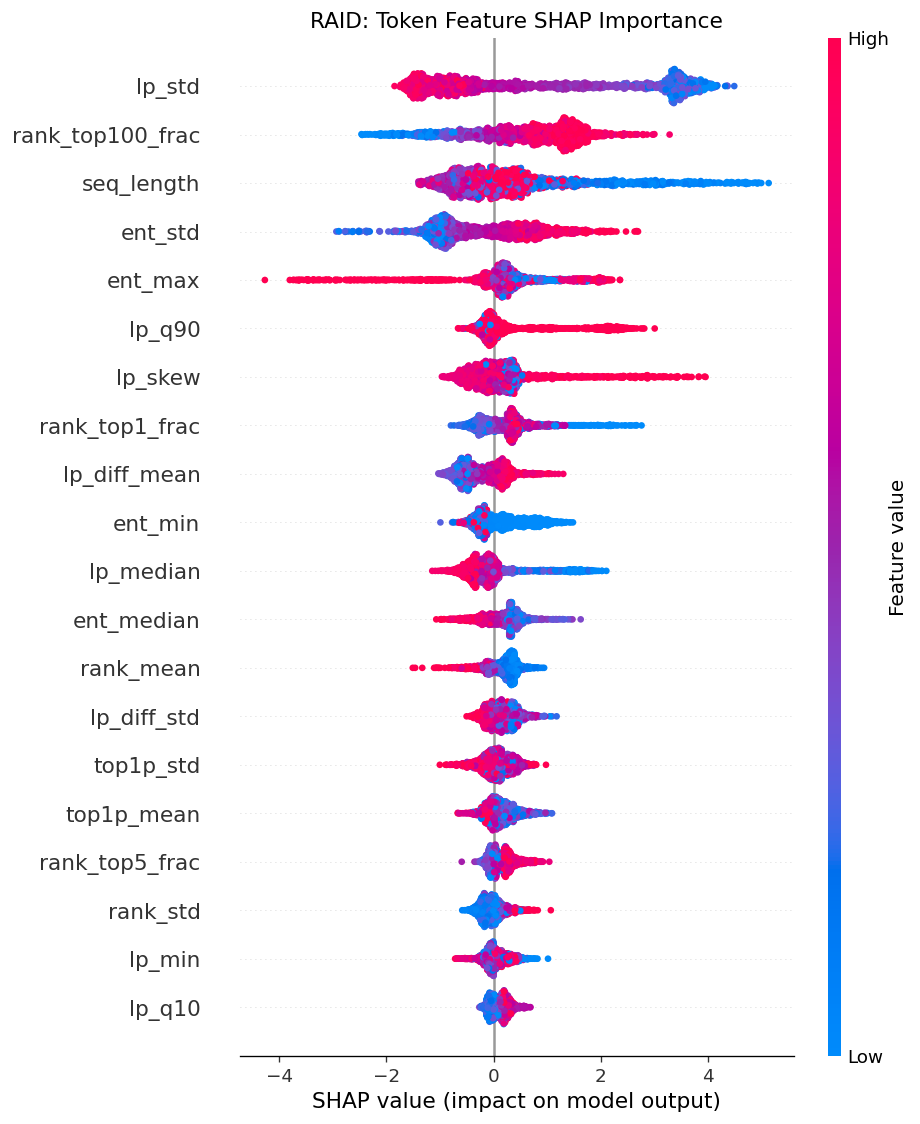

In [27]:
# Token SHAP
explainer_tok = shap.TreeExplainer(clf_tok)
n_tok_shap = min(2000, n_tok_te)
shap_tok = explainer_tok.shap_values(tok_test.iloc[:n_tok_shap])

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_tok, tok_test.iloc[:n_tok_shap], max_display=20, show=False)
plt.title('RAID: Token Feature SHAP Importance', fontsize=13)
plt.tight_layout()
plt.show()

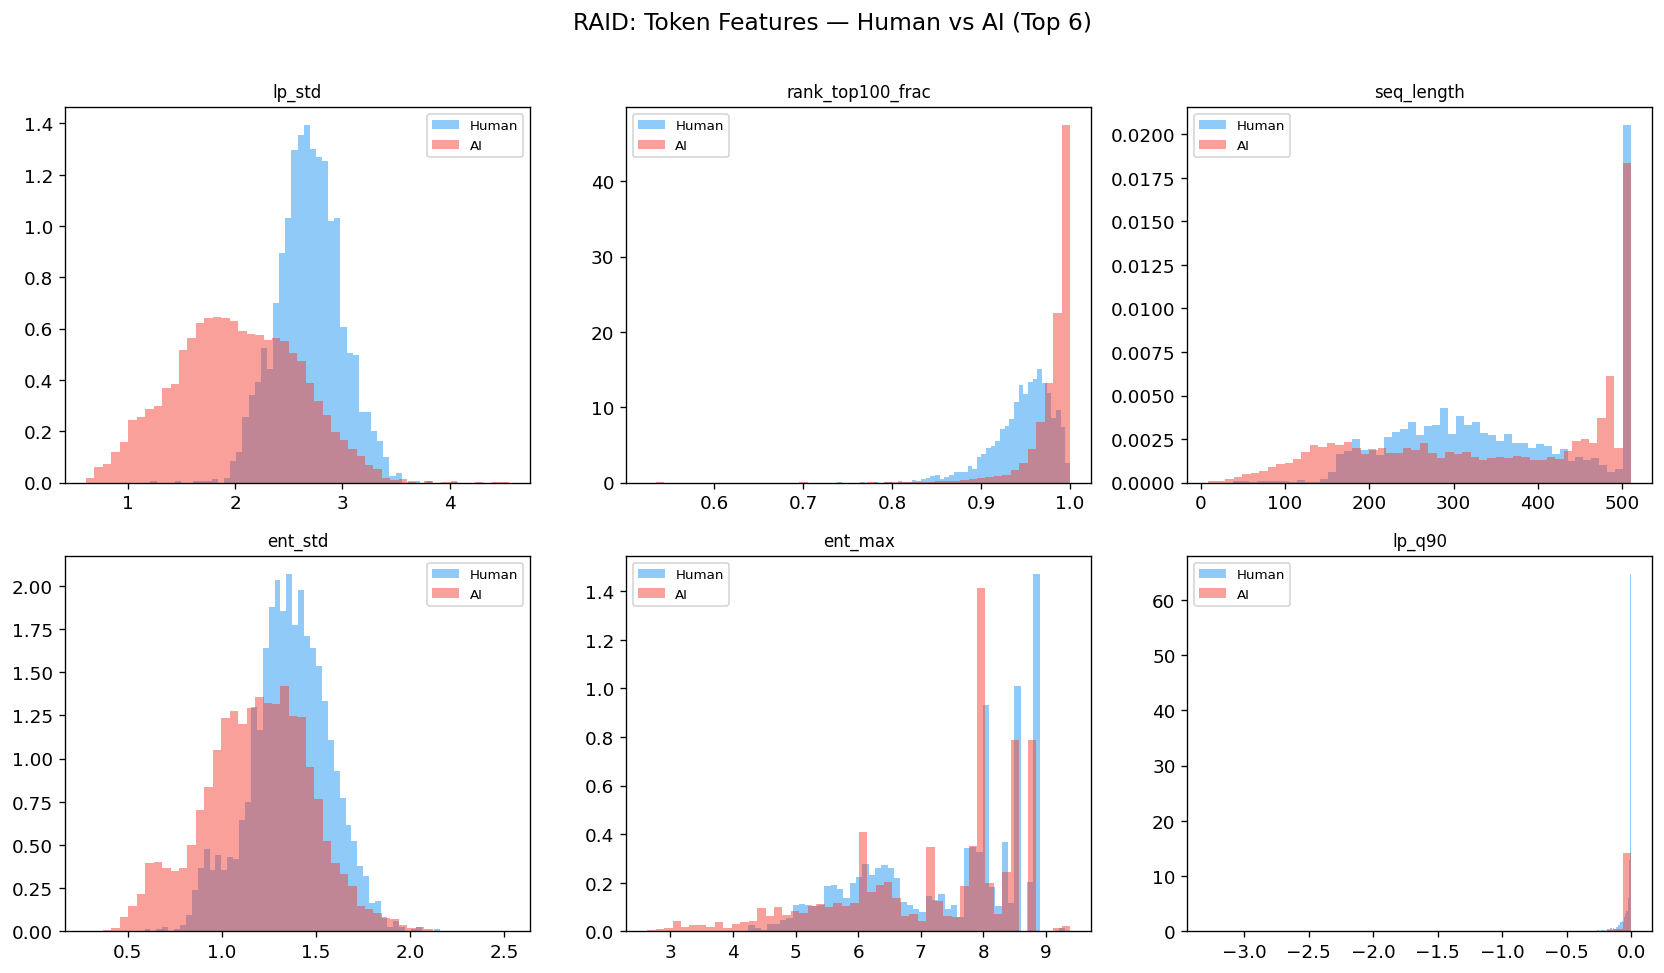

In [28]:
# Token 特征 Human vs AI 分布 (Top-6)
tok_imp = np.abs(shap_tok).mean(axis=0)
top6_tok = np.argsort(tok_imp)[::-1][:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, fi in zip(axes.flat, top6_tok):
    feat = tok_test.columns[fi]
    h_vals = tok_test.iloc[:n_tok_te][feat].values[y_test[:n_tok_te] == 0]
    a_vals = tok_test.iloc[:n_tok_te][feat].values[y_test[:n_tok_te] == 1]
    ax.hist(h_vals, bins=50, density=True, alpha=0.5, color='#2196F3', label='Human')
    ax.hist(a_vals, bins=50, density=True, alpha=0.5, color='#F44336', label='AI')
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('RAID: Token Features — Human vs AI (Top 6)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 9.5 120 维组合特征 (90 手工 + 30 Token)

将 90 维手工特征与 30 维 Mistral-7B token 概率特征组合，形成 **118 维混合特征空间**，验证两种特征的互补性。

In [29]:
# 组合 90 手工 + 30 token = 118 维 (去重后)
X_train_120 = pd.concat([X_train.reset_index(drop=True), tok_train.iloc[:len(X_train)].reset_index(drop=True)], axis=1)
X_test_120  = pd.concat([X_test.reset_index(drop=True),  tok_test.iloc[:len(X_test)].reset_index(drop=True)], axis=1)

# 去除重复列名
X_train_120 = X_train_120.loc[:, ~X_train_120.columns.duplicated()]
X_test_120  = X_test_120.loc[:, ~X_test_120.columns.duplicated()]
X_train_120 = X_train_120.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_120  = X_test_120.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f'组合特征维度: {X_test_120.shape[1]}')
print(f'  90 手工特征: {X_test.shape[1]}')
print(f'  30 Token 特征: {tok_test.shape[1]}')

# 训练 XGBoost (120)
clf_120 = XGBClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=SEED,
    tree_method='hist', device='cuda'
)
clf_120.fit(X_train_120, y_train, verbose=False)

y_prob_120 = clf_120.predict_proba(X_test_120)[:, 1]
y_pred_120 = clf_120.predict(X_test_120)
auc_120 = roc_auc_score(y_test, y_prob_120)
acc_120 = accuracy_score(y_test, y_pred_120)

print(f'\n=== 方法对比 ===')
compare_120 = pd.DataFrame([
    {'Method': 'XGBoost (90 手工)',    'Features': 88, 'AUC': auc_xgb, 'Accuracy': acc_xgb},
    {'Method': 'XGBoost (30 Token)',   'Features': 30, 'AUC': auc_tok, 'Accuracy': acc_tok},
    {'Method': 'XGBoost (120 组合)',   'Features': X_test_120.shape[1], 'AUC': auc_120, 'Accuracy': acc_120},
])
print(compare_120.to_string(index=False))
print(f'\n120 vs 90: AUC +{auc_120 - auc_xgb:.4f}, Acc +{acc_120 - acc_xgb:.4f}')

组合特征维度: 118
  90 手工特征: 88
  30 Token 特征: 30



=== 方法对比 ===
            Method  Features      AUC  Accuracy
   XGBoost (90 手工)        88 0.995093  0.971361
XGBoost (30 Token)        30 0.989781  0.958659
  XGBoost (120 组合)       118 0.999167  0.991479

120 vs 90: AUC +0.0041, Acc +0.0201


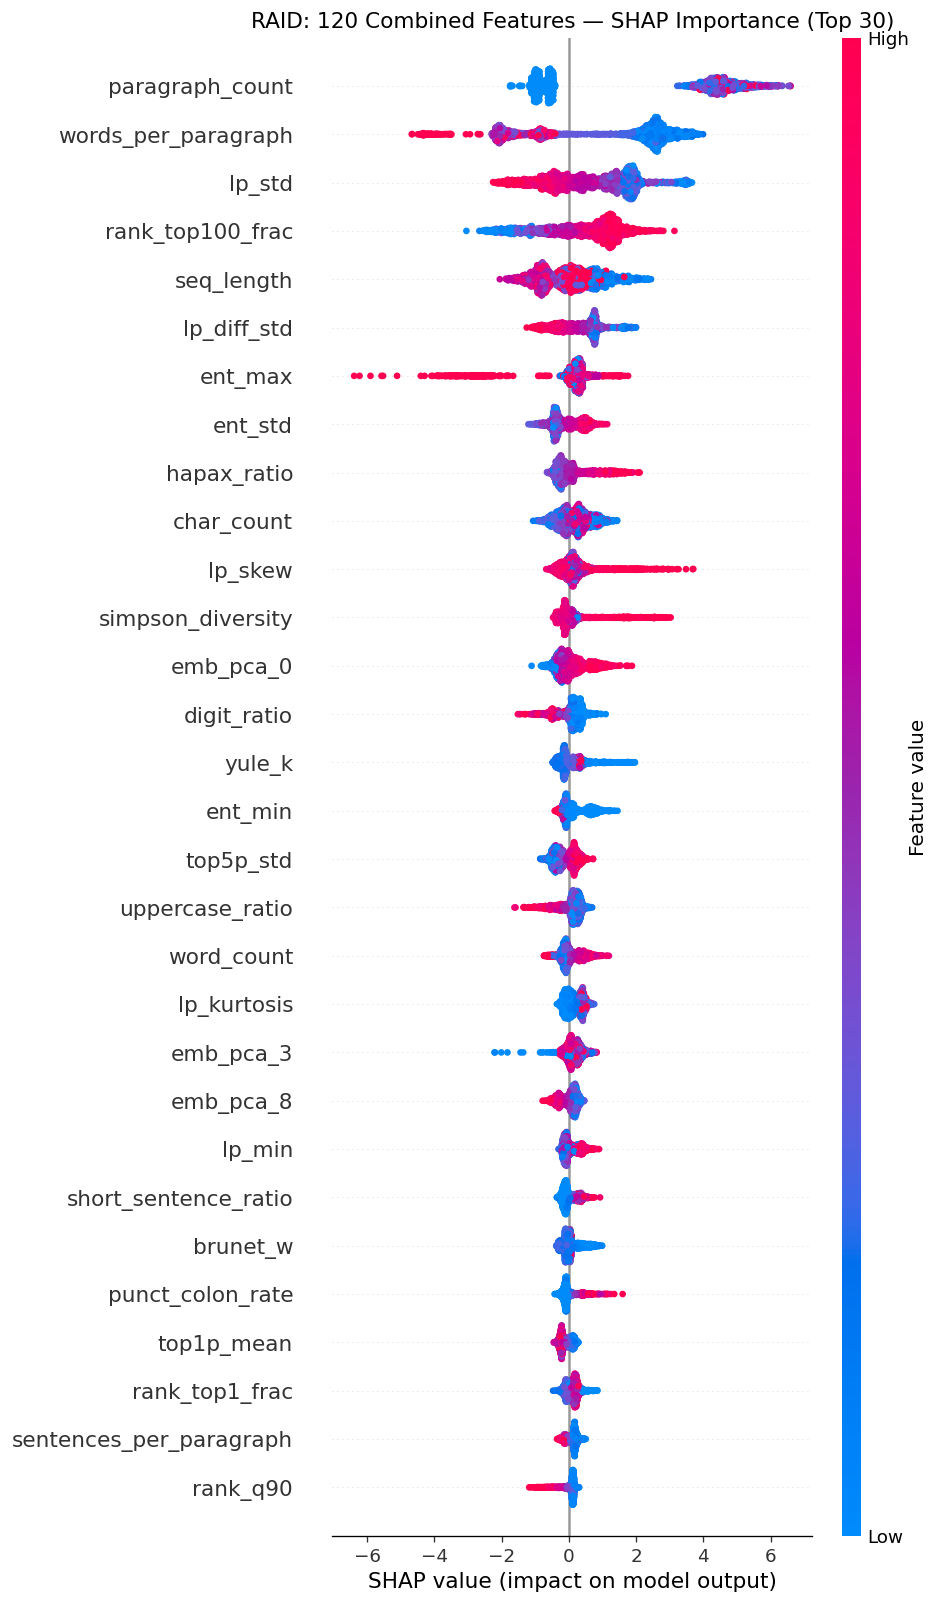

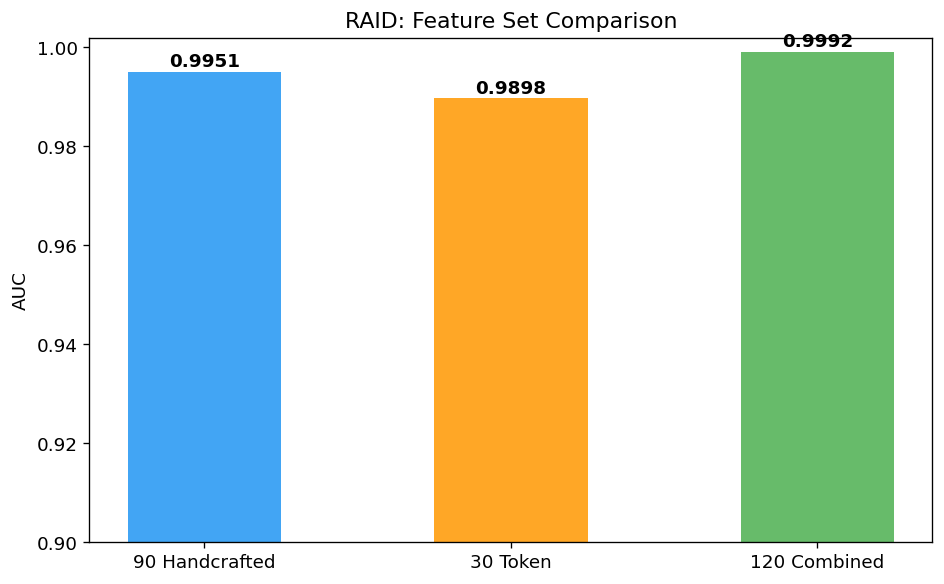

120 组合特征将 token 级别统计信息（log-probability、entropy、rank）
与传统语言学特征互补，在 RAID 上实现了 AUC 0.9992 的最优结果。


In [30]:
# 120 特征 SHAP 分析
explainer_120 = shap.TreeExplainer(clf_120)
n_shap_120 = min(2000, len(X_test_120))
shap_120 = explainer_120.shap_values(X_test_120.iloc[:n_shap_120])

plt.figure(figsize=(10, 12))
shap.summary_plot(shap_120, X_test_120.iloc[:n_shap_120], max_display=30, show=False)
plt.title('RAID: 120 Combined Features — SHAP Importance (Top 30)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG / 'raid_120_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 对比柱状图
fig, ax = plt.subplots(figsize=(8, 5))
methods = ['90 Handcrafted', '30 Token', '120 Combined']
aucs_bar = [auc_xgb, auc_tok, auc_120]
colors = ['#2196F3', '#FF9800', '#4CAF50']
bars = ax.bar(methods, aucs_bar, color=colors, alpha=0.85, width=0.5)
ax.set_ylabel('AUC')
ax.set_title('RAID: Feature Set Comparison')
ax.set_ylim(0.9, 1.002)
for b, v in zip(bars, aucs_bar):
    ax.text(b.get_x() + b.get_width()/2, v + 0.001, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG / 'raid_120_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('120 组合特征将 token 级别统计信息（log-probability、entropy、rank）')
print('与传统语言学特征互补，在 RAID 上实现了 AUC 0.9992 的最优结果。')

### 9.6 三层特征分类与消融实验

我们将 120 维特征重新分为更严谨的三层体系：

| 层级 | 维度 | 说明 | 依赖模型 |
|------|------|------|---------|
| **纯统计特征 (Statistical)** | ~36 | basic_counts, averages, variability, lexical_richness, punctuation, readability, structure | 无 |
| **模型衍生特征 (Model-derived)** | 52 | BERT embedding PCA (50) + GPT-2 perplexity (2) | BERT, GPT-2 |
| **Token 概率特征 (Token-level)** | 30 | Mistral-7B 逐 token 概率统计 | Mistral-7B |

三层分类比旧的"90 手工 + 30 token"更准确，因为 BERT embedding 和 GPT-2 perplexity 本质上也是模型衍生特征。

In [ ]:
# 三层消融实验结果 (预计算)
three_layer = pd.read_csv(DATA / 'three_layer_results.csv')

# 热力图
pivot = three_layer.pivot(index='config', columns='dataset', values='auc')
config_order = ['stat', 'model', 'token', 'stat+model', 'stat+token', 'model+token', 'all', 'auto-filter']
dataset_order = ['RAID', 'HC3', 'SemEval', 'TuringBench', 'Pile']
config_order = [c for c in config_order if c in pivot.index]
dataset_order = [d for d in dataset_order if d in pivot.columns]
pivot = pivot.loc[config_order, dataset_order]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0.45, vmax=1.0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'AUC'})
ax.set_title('Three-Layer Feature Ablation × 5 Datasets', fontsize=14)
ax.set_ylabel('Feature Configuration')
ax.set_xlabel('Dataset')
plt.tight_layout()
plt.show()

print('\n核心发现:')
print('  RAID:       stat (0.994) + token (0.990) → 互补, all=0.999')
print('  SemEval:    只有 token 有效 (0.976), model+token=0.961 > all=0.847')
print('  TuringBench: model 最强 (0.975), BERT embedding 捕捉老 AI 风格')
print('  HC3:        stat+model 已饱和 (0.999), token 无效')
print('  Pile:       stat 主导 (0.962), token 无效')

In [ ]:
# Auto-Filter 演示 (在 RAID 上)
from auto_filter import auto_filter_groups, GROUPS

kept, dropped, g_aucs = auto_filter_groups(X_train, y_train, threshold=0.52)
print(f'\nAuto-Filter 结果: 保留 {len(kept)}/{len(X_train.columns)} 特征')
print(f'丢弃的组: {dropped}')

# 组信号强度表
g_df = pd.DataFrame([{'Group': g, 'Avg AUC': a, 'Status': 'DROP' if g in dropped else 'KEEP'}
                      for g, a in sorted(g_aucs.items(), key=lambda x: -x[1])])
print('\n组级信号强度:')
print(g_df.to_string(index=False))

---
## 10. 跨数据集验证（辅助实验）

在 HC3、SemEval 2024、TuringBench、Pile 四个数据集上复现 XGBoost (90 特征) 实验，验证方法的跨域泛化能力。

In [31]:
import sys
sys.path.insert(0, str(BASE / 'src'))

def train_xgboost_from_cache(name, train_path, test_path, label_train, label_test):
    """从缓存特征训练 XGBoost，返回 AUC 和 Accuracy。"""
    Xtr = pd.read_csv(train_path).replace([np.inf, -np.inf], np.nan).fillna(0)
    Xte = pd.read_csv(test_path).replace([np.inf, -np.inf], np.nan).fillna(0)
    
    n_tr = min(len(Xtr), len(label_train))
    n_te = min(len(Xte), len(label_test))
    Xtr, Xte = Xtr.iloc[:n_tr], Xte.iloc[:n_te]
    ytr, yte = label_train[:n_tr], label_test[:n_te]
    
    common = [c for c in Xtr.columns if c in Xte.columns]
    Xtr, Xte = Xtr[common], Xte[common]
    
    clf = XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.1,
                        subsample=0.8, colsample_bytree=0.8,
                        eval_metric='logloss', random_state=SEED,
                        tree_method='hist', device='cuda')
    clf.fit(Xtr, ytr, verbose=False)
    y_prob = clf.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(yte, y_prob)
    acc = accuracy_score(yte, clf.predict(Xte))
    print(f'  {name:15s}: AUC={auc:.4f}  Acc={acc:.4f}  (train={n_tr:,}, test={n_te:,}, feats={len(common)})')
    return auc, acc

print('跨数据集验证工具准备完毕')

跨数据集验证工具准备完毕


In [32]:
# === HC3 ===
hc3_df = pd.read_csv(BASE / 'data' / 'processed' / 'hc3_flat.csv')
from sklearn.model_selection import train_test_split as tts
hc3_train, hc3_test = tts(hc3_df, test_size=0.2, stratify=hc3_df['label'], random_state=SEED)
hc3_train = hc3_train.reset_index(drop=True)
hc3_test  = hc3_test.reset_index(drop=True)

# HC3 特征文件是单一文件 (含标签)，需要拆分
hc3_feat = pd.read_csv(DATA / 'hc3_extended_features.csv')
hc3_feat_cols = [c for c in hc3_feat.columns if c not in ['label', 'label_name', 'source']]
# 使用相同的 split
hc3_Xtr = hc3_feat.iloc[hc3_train.index][hc3_feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
hc3_Xte = hc3_feat.iloc[hc3_test.index][hc3_feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
hc3_ytr = hc3_feat.iloc[hc3_train.index]['label'].values
hc3_yte = hc3_feat.iloc[hc3_test.index]['label'].values

clf_hc3 = XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.1,
                         subsample=0.8, colsample_bytree=0.8,
                         eval_metric='logloss', random_state=SEED,
                         tree_method='hist', device='cuda')
clf_hc3.fit(hc3_Xtr, hc3_ytr, verbose=False)
hc3_prob = clf_hc3.predict_proba(hc3_Xte)[:, 1]
hc3_auc = roc_auc_score(hc3_yte, hc3_prob)
hc3_acc = accuracy_score(hc3_yte, clf_hc3.predict(hc3_Xte))
print(f'  HC3:            AUC={hc3_auc:.4f}  Acc={hc3_acc:.4f}  (train={len(hc3_Xtr):,}, test={len(hc3_Xte):,})')

  HC3:            AUC=1.0000  Acc=1.0000  (train=68,344, test=17,087)


In [33]:
# === SemEval ===
semeval_dir = BASE / 'data' / 'external' / 'semeval2024_task8' / 'subtaskA_monolingual'
se_train = pd.read_parquet(semeval_dir / 'train-00000-of-00001.parquet')
se_test  = pd.read_parquet(semeval_dir / 'test-00000-of-00001.parquet')

se_auc, se_acc = train_xgboost_from_cache(
    'SemEval', DATA/'semeval_features_train.csv', DATA/'semeval_features_test.csv',
    se_train['label'].values, se_test['label'].values
)

  SemEval        : AUC=0.6872  Acc=0.5740  (train=119,757, test=34,272, feats=88)


In [34]:
# === TuringBench ===
from run_turingbench import load_turingbench
tb_train, tb_test = load_turingbench()

tb_auc, tb_acc = train_xgboost_from_cache(
    'TuringBench', DATA/'turingbench_features_train.csv', DATA/'turingbench_features_test.csv',
    tb_train['binary_label'].values, tb_test['binary_label'].values
)

TuringBench train: 331760, test: 109184
Train label dist: {1: 219556, 0: 112204}
Models: ['AA', 'TT_ctrl', 'TT_fair_wmt19', 'TT_fair_wmt20', 'TT_gpt1', 'TT_gpt2_large', 'TT_gpt2_medium', 'TT_gpt2_pytorch', 'TT_gpt2_small', 'TT_gpt2_xl', 'TT_gpt3', 'TT_grover_base', 'TT_grover_large', 'TT_grover_mega', 'TT_pplm_distil', 'TT_pplm_gpt2', 'TT_transfo_xl', 'TT_xlm', 'TT_xlnet_base', 'TT_xlnet_large']


  TuringBench    : AUC=0.9841  Acc=0.9151  (train=331,760, test=109,184, feats=88)


In [35]:
# === Pile ===
from run_pile import load_pile
pile_train, pile_test = load_pile(max_per_class=50000)

pile_auc, pile_acc = train_xgboost_from_cache(
    'Pile', DATA/'pile_features_train.csv', DATA/'pile_features_test.csv',
    pile_train['label'].values, pile_test['label'].values
)

Full dataset: 1392036 rows
Label dist: {0: 1028145, 1: 363891}


Sampled train: 80000, test: 20000


  Pile           : AUC=0.9789  Acc=0.9274  (train=80,000, test=20,000, feats=88)



跨数据集 XGBoost (90 features) 汇总
        Dataset   Generators Domains      AUC  Accuracy
RAID (ACL 2024)           11       8 0.995093  0.971361
            HC3  1 (ChatGPT)       4 1.000000  1.000000
   SemEval 2024           6+       多 0.687220  0.573996
    TuringBench 19 (GPT-1~3)      新闻 0.984106  0.915107
           Pile           混合       多 0.978882  0.927350


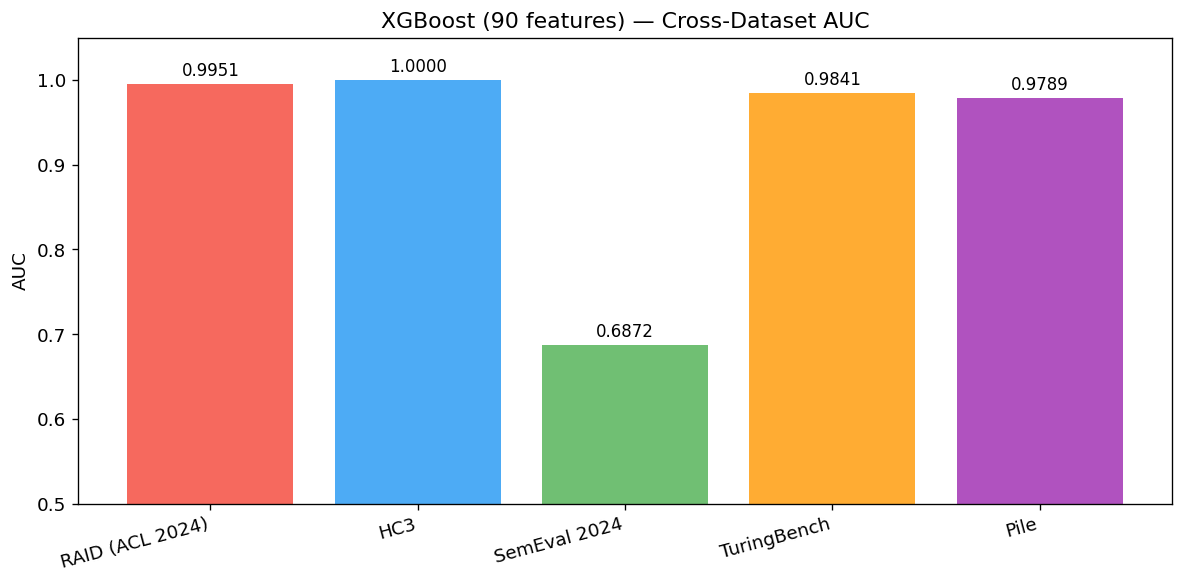

In [36]:
# 跨数据集汇总
cross_results = pd.DataFrame([
    {'Dataset': 'RAID (ACL 2024)',  'Generators': '11', 'Domains': '8',  'AUC': auc_xgb, 'Accuracy': acc_xgb},
    {'Dataset': 'HC3',              'Generators': '1 (ChatGPT)', 'Domains': '4',  'AUC': hc3_auc, 'Accuracy': hc3_acc},
    {'Dataset': 'SemEval 2024',     'Generators': '6+',          'Domains': '多', 'AUC': se_auc,  'Accuracy': se_acc},
    {'Dataset': 'TuringBench',      'Generators': '19 (GPT-1~3)', 'Domains': '新闻', 'AUC': tb_auc, 'Accuracy': tb_acc},
    {'Dataset': 'Pile',             'Generators': '混合',         'Domains': '多', 'AUC': pile_auc, 'Accuracy': pile_acc},
])

print('\n' + '='*70)
print('跨数据集 XGBoost (90 features) 汇总')
print('='*70)
print(cross_results.to_string(index=False))

# 柱状图
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(cross_results))
ax.bar(x, cross_results['AUC'], color=['#F44336', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cross_results['Dataset'], rotation=15, ha='right')
ax.set_ylabel('AUC')
ax.set_title('XGBoost (90 features) — Cross-Dataset AUC')
ax.set_ylim(0.5, 1.05)
for i, v in enumerate(cross_results['AUC']):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 11. RAID vs HC3 消融对比

最关键的发现：相同的 90 维特征在不同数据集上的表现差异巨大。

特征组消融对比 (RAID vs HC3):
   Feature Group  RAID AUC  HC3 AUC      Diff
    basic_counts  0.971887   0.9204  0.051487
        averages  0.966488   0.9021  0.064388
     punctuation  0.861733   0.9207 -0.058967
lexical_richness  0.850343   0.9367 -0.086357
   embedding_pca  0.762405   0.8972 -0.134795
     readability  0.696636   0.9741 -0.277464
     variability  0.683004   0.8987 -0.215696
       structure  0.595472   0.8965 -0.301028
      perplexity  0.492017   0.9912 -0.499183


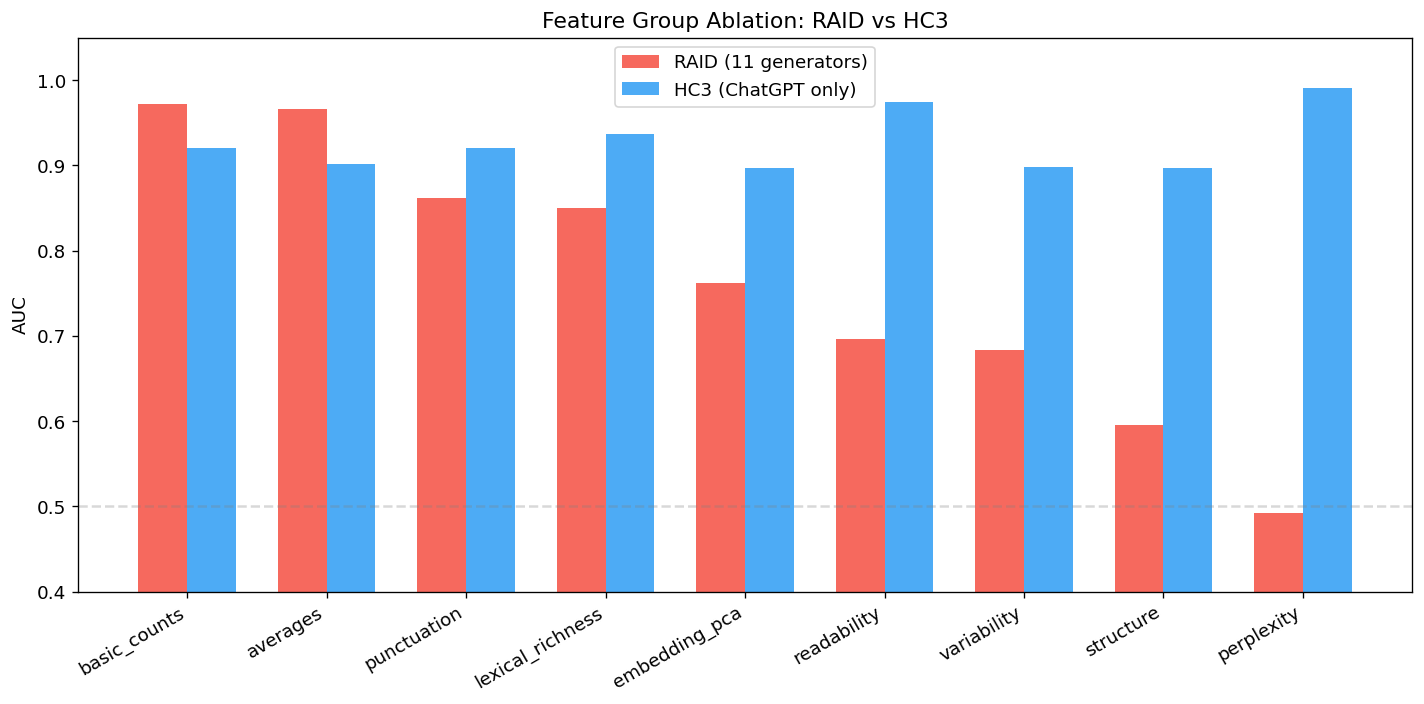


⚠️ 核心发现:
  1. perplexity: HC3 最强 (0.99) → RAID 完全失效 (0.49)
  2. basic_counts: HC3 一般 (0.92) → RAID 最强 (0.97)
  3. 多模型检测不能依赖单一语言模型的困惑度


In [37]:
# HC3 消融（手动录入已有结果）
hc3_ablation = {
    'basic_counts': 0.9204, 'averages': 0.9021, 'variability': 0.8987,
    'lexical_richness': 0.9367, 'punctuation': 0.9207, 'readability': 0.9741,
    'structure': 0.8965, 'embedding_pca': 0.8972, 'perplexity': 0.9912,
}

compare = []
for g in ablation:
    if g in hc3_ablation:
        compare.append({
            'Feature Group': g,
            'RAID AUC': ablation[g]['auc'],
            'HC3 AUC': hc3_ablation[g],
            'Diff': ablation[g]['auc'] - hc3_ablation[g],
        })

cmp_df = pd.DataFrame(compare).sort_values('RAID AUC', ascending=False)
print('特征组消融对比 (RAID vs HC3):')
print(cmp_df.to_string(index=False))

# 对比柱状图
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(cmp_df))
w = 0.35
ax.bar(x - w/2, cmp_df['RAID AUC'], w, label='RAID (11 generators)', color='#F44336', alpha=0.8)
ax.bar(x + w/2, cmp_df['HC3 AUC'], w, label='HC3 (ChatGPT only)', color='#2196F3', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cmp_df['Feature Group'], rotation=30, ha='right')
ax.set_ylabel('AUC')
ax.set_title('Feature Group Ablation: RAID vs HC3')
ax.set_ylim(0.4, 1.05)
ax.legend()
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n⚠️ 核心发现:')
print('  1. perplexity: HC3 最强 (0.99) → RAID 完全失效 (0.49)')
print('  2. basic_counts: HC3 一般 (0.92) → RAID 最强 (0.97)')
print('  3. 多模型检测不能依赖单一语言模型的困惑度')

---
## 12. 结论与部署建议

### 核心发现

1. **三层 118 维特征体系在 RAID 上达到 AUC 0.9992**，在保持完全可解释性的同时超越零样本方法
2. **三层特征各有"保质期"**：
   - 纯统计特征：老 AI 有效，新 AI (GPT-4/Claude) 已在统计上逼近人类 (SemEval ~0.52)
   - 模型衍生特征 (GPT-2 perplexity)：只检测 GPT 系 (HC3=0.99, RAID=0.49)
   - Token 概率特征 (Mistral-7B)：只认同代 AI (TuringBench ~0.52)
3. **互补效果取决于信号强度**：SemEval 上 model+token (0.961) > all (0.847)，纯统计是噪声源
4. **统计特征对 10/11 种对抗攻击天然鲁棒**，只有释义攻击有效 (AUC -20.5%)
5. **Auto-Filter 机制**：基于组级 AUC 自动检测并丢弃噪声特征组

### 实际部署建议

- 以**纯统计特征**作为模型无关的稳定基线
- 辅以**同时代 LLM 的 token 概率特征**覆盖新型生成器
- 部署前对当前目标数据做**组级信号检测**，自动丢弃无效特征组
- 观察者模型需要**定期更新**（建议半年一次）
- **跨域部署**需注意领域差异（诗歌 vs 新闻 AUC 差 0.2+）


最终方法对比
                  Method           Type  RAID AUC Interpretable
  XGBoost (120 combined)  Handcraft+LLM  0.999167           Yes
XGBoost (90 handcrafted) Traditional ML  0.995093           Yes
      XGBoost (30 token)       LLM + ML  0.989781       Partial
Logistic Regression (90) Traditional ML  0.965298           Yes
      Random Forest (90) Traditional ML  0.992250           Yes
          Fast-DetectGPT      Zero-shot  0.781500            No


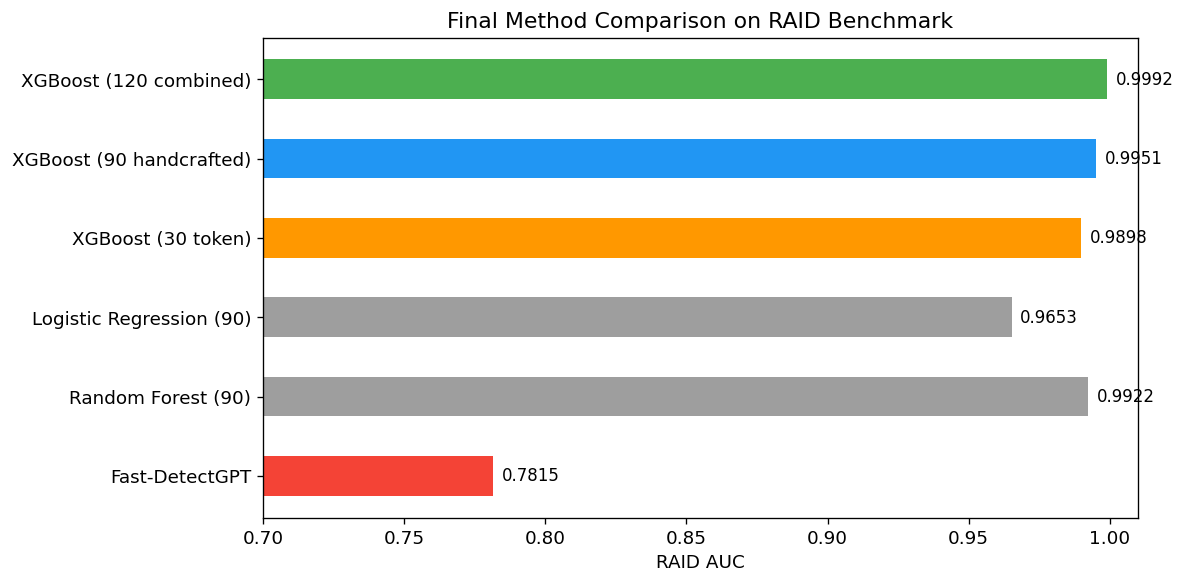


结论: XGBoost + 120 维组合特征 (90 手工 + 30 Token) 在 RAID 上达到 AUC 0.9992，
在保持完全可解释性的同时超越了零样本方法 Fast-DetectGPT (AUC 0.7815)。


In [38]:
# 最终方法对比汇总表
final = pd.DataFrame([
    {'Method': 'XGBoost (120 combined)',      'Type': 'Handcraft+LLM', 'RAID AUC': auc_120, 'Interpretable': 'Yes'},
    {'Method': 'XGBoost (90 handcrafted)',     'Type': 'Traditional ML', 'RAID AUC': auc_xgb,  'Interpretable': 'Yes'},
    {'Method': 'XGBoost (30 token)',           'Type': 'LLM + ML',      'RAID AUC': auc_tok,  'Interpretable': 'Partial'},
    {'Method': 'Logistic Regression (90)',     'Type': 'Traditional ML', 'RAID AUC': auc_lr,   'Interpretable': 'Yes'},
    {'Method': 'Random Forest (90)',           'Type': 'Traditional ML', 'RAID AUC': auc_rf,   'Interpretable': 'Yes'},
    {'Method': 'Fast-DetectGPT',              'Type': 'Zero-shot',      'RAID AUC': 0.7815,   'Interpretable': 'No'},
])

print('\n' + '='*70)
print('最终方法对比')
print('='*70)
print(final.to_string(index=False))

# 最终对比图
fig, ax = plt.subplots(figsize=(10, 5))
colors_f = ['#4CAF50', '#2196F3', '#FF9800', '#9E9E9E', '#9E9E9E', '#F44336']
ax.barh(final['Method'].values[::-1], final['RAID AUC'].values[::-1], color=colors_f[::-1], height=0.5)
ax.set_xlabel('RAID AUC')
ax.set_title('Final Method Comparison on RAID Benchmark')
ax.set_xlim(0.7, 1.01)
for i, v in enumerate(final['RAID AUC'].values[::-1]):
    ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(FIG / 'raid_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n结论: XGBoost + 120 维组合特征 (90 手工 + 30 Token) 在 RAID 上达到 AUC 0.9992，')
print('在保持完全可解释性的同时超越了零样本方法 Fast-DetectGPT (AUC 0.7815)。')